# Bayes Consistency in LLM Forecasting

This notebook analyzes how well an LLM respects the Law of Total Probability when
making four correlated forecasts for Metaculus conditional question pairs:

- **P(A)** — probability the parent/condition question resolves YES  
- **P(B)** — unconditional probability the child question resolves YES  
- **P(B|A)** — probability of child resolving YES *given* parent resolves YES  
- **P(B|¬A)** — probability of child resolving YES *given* parent resolves NO  

A coherent forecaster should satisfy the **Law of Total Probability**:

$$P(B) = P(B|A) \cdot P(A) + P(B|\neg A) \cdot (1 - P(A))$$

Deviation from this identity is our measure of **Bayesian inconsistency**.

In [9]:
import os
import sys
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

# Allow imports from bayes_bot.py
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from src.bayes_bot import load_pairs_from_csv, compute_consistency_metrics

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

CSV_PATH = 'data/metaculus_conditionals_2026-03.csv'

## 1. Consistency Formula

Our primary metric is **absolute LTP error**:

$$\text{error} = |P(B) - [P(B|A) \cdot P(A) + P(B|\neg A) \cdot (1-P(A))]|$$

We also compute two normalised variants:

- **Relative error** = error / P(B)_expected — penalises proportionally (useful for comparing across questions with different base rates)
- **Calibrated error** = error / √(P(B)·(1−P(B))) — penalises errors more when the forecaster is already confident about P(B)

The absolute error is the most interpretable for reporting and is used as the primary metric throughout.

## 2. Community Baseline

Before running the LLM, we compute consistency scores for the community (crowd) predictions
across all 837 pairs in the CSV. This gives us a baseline to compare the LLM against.

The results are striking: community forecasts show a mean absolute LTP error of ~0.13 with a
long right tail reaching above 0.70. In other words, the crowd routinely states probabilities
that are internally contradictory by 10+ percentage points — and in the worst cases by over 70
points. These gaps are not subtle rounding artifacts; they imply large theoretical arbitrage
opportunities. A bettor who trusted three of the four community values and took the opposite
side on the inconsistent one could, in principle, construct portfolios with substantial expected
edge. The fact that these inconsistencies persist suggests either
that forecasters treat each question in isolation without checking cross-question coherence, or
that the aggregate forecast structure makes it difficult to exploit these mispricings in practice.

In [10]:
pairs = load_pairs_from_csv(CSV_PATH)
print(f"Loaded {len(pairs)} conditional pairs.")

# Compute community consistency for all pairs
community_records = []
for p in pairs:
    m = compute_consistency_metrics(
        p.community_p_a, p.community_p_b,
        p.community_p_b_given_a, p.community_p_b_given_na,
    )
    community_records.append({
        'conditional_post_id': p.conditional_post_id,
        'condition_title': p.condition_title,
        'child_title': p.child_title,
        'p_a': p.community_p_a,
        'p_b': p.community_p_b,
        'p_b_given_a': p.community_p_b_given_a,
        'p_b_given_na': p.community_p_b_given_na,
        **m,
    })

community_df = pd.DataFrame(community_records)


Loaded 31 conditional pairs.


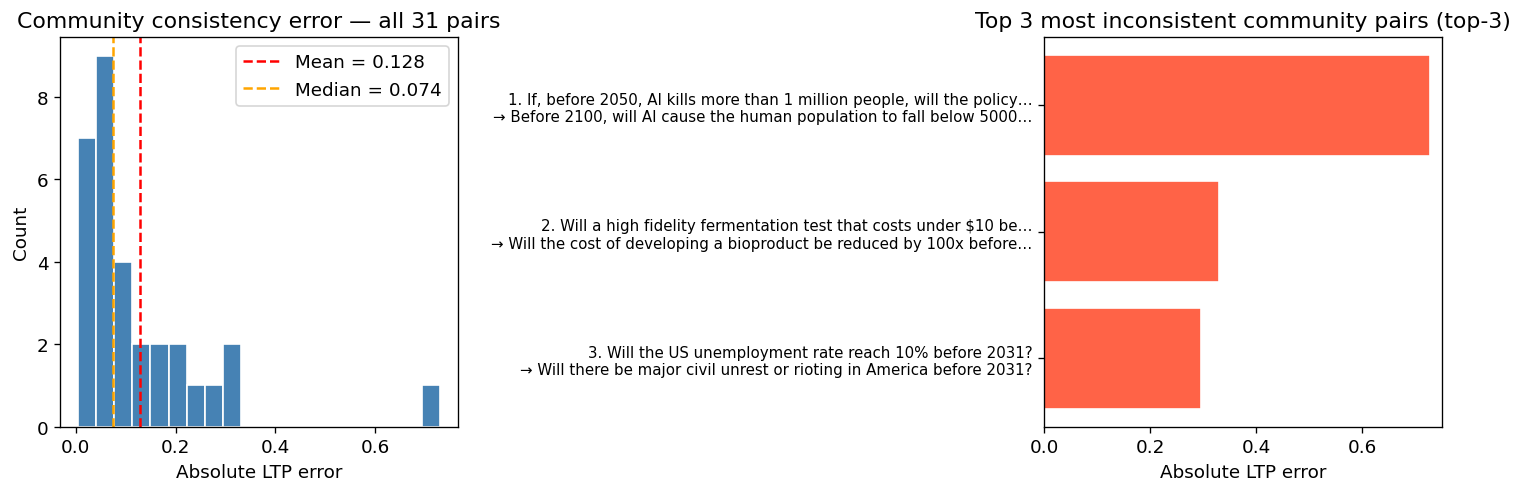

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Left: histogram
ax0 = axes[0]
ax0.hist(community_df['consistency_error'], bins=min(20, len(community_df)), color='steelblue', edgecolor='white')
ax0.axvline(community_df['consistency_error'].mean(), color='red', linestyle='--',
           label=f"Mean = {community_df['consistency_error'].mean():.3f}")
ax0.axvline(community_df['consistency_error'].median(), color='orange', linestyle='--',
           label=f"Median = {community_df['consistency_error'].median():.3f}")
ax0.set_xlabel('Absolute LTP error')
ax0.set_ylabel('Count')
ax0.set_title(f'Community consistency error — all {len(community_df)} pairs')
ax0.legend()

# Right: top-3 bar chart (static, compact)
n_top = min(3, len(community_df))
top_n = community_df.nlargest(n_top, 'consistency_error').copy()

# small helper to avoid wrapping long titles in y-axis labels
import textwrap

def summarize_text(text, max_len=72):
    if len(text) <= max_len:
        return text
    shortened = textwrap.shorten(text, width=max_len, placeholder='…')
    return shortened

# Build consistent, aligned label strings with fixed-indent second line
top_n['short_condition'] = top_n['condition_title'].apply(lambda t: summarize_text(t))
top_n['short_child'] = top_n['child_title'].apply(lambda t: summarize_text(t))
top_n['rank'] = range(1, len(top_n) + 1)

top_n['label'] = top_n.apply(
    lambda row: f"{row['rank']:d}. {row['short_condition']}\n    → {row['short_child']}",
    axis=1
)

# reverse so worst pair appears at the top in the horizontal bar chart
top_n = top_n.iloc[::-1]

ax1 = axes[1]
ax1.barh(top_n['label'], top_n['consistency_error'], color='tomato', edgecolor='white')
ax1.set_xlabel('Absolute LTP error')
ax1.set_title(f'Top {n_top} most inconsistent community pairs (top-3)')
ax1.set_xmargin(0.03)
ax1.tick_params(axis='y', labelsize=9)

plt.show()

## 3. LLM Forecasts

We use `BayesConsistencyBot`, which extends the Metaculus `SpringTemplateBot2026` template.
For each conditional question pair the bot makes **5 LLM calls** organized in two batches:

1. **Research call** — a single LLM call summarizes relevant context for the question pair.
2. **Batch 1 (parallel):** P(A) and P(B) are forecast independently, both using the research context.
3. **Batch 2 (parallel):** P(B|A) and P(B|¬A) are forecast independently, enriched with the
   reasoning from Batch 1 so the conditionals are informed by the model's marginal beliefs.

This two-batch design keeps wall-clock time at ~2× LLM latency per pair (vs 4× if sequential)
while preserving the most useful context chain. The bot sets `research_reports_per_question=1`
and `predictions_per_research_report=1`, so each pair produces exactly **1 research report**
and **4 forecast calls** — no redundant generations. Pairs are themselves forecast in parallel
via `asyncio.gather`, so a full 31-pair sample completes in roughly the time of the slowest
single pair.

The results here use **Claude Opus 4.6** (`openrouter/anthropic/claude-opus-4-6`) as the oracle/frontier model.

In [12]:
result_files = sorted(glob.glob('results/llm_forecasts_*.csv'))
if not result_files:
    raise FileNotFoundError(
        "No results found. Run: poetry -C ../metac-bot-template run python run_trial.py"
    )

# Use the most recent results file
# results_path = result_files[-1]
results_path = 'results/llm_forecasts_opus_oracle.csv'
print(f"Loading: {results_path}")
llm_df = pd.read_csv(results_path)
print(f"Loaded {len(llm_df)} rows.")
llm_df.head(3)


Loading: results/llm_forecasts_opus_oracle.csv
Loaded 31 rows.


,conditional_post_id,condition_title,child_title,community_p_a,community_p_b,community_p_b_given_a,community_p_b_given_na,community_p_b_expected,community_consistency_error,llm_p_a,llm_p_b,llm_p_b_given_a,llm_p_b_given_na,llm_p_b_expected,llm_consistency_error,llm_relative_error,llm_calibrated_error
0,25661,Will a universal allogeneic cell therapy platf...,"Will age-adjusted cancer deaths per 100,000 pe...",0.500,0.5015,0.65,0.420,0.5350,0.0335,0.22,0.22,0.28,0.17,0.1942,0.0258,0.1329,0.0623
1,17735,Will OpenAI announce that it has solved the co...,Will humans go extinct before 2100?,0.005,0.0200,0.02,0.034,0.0339,0.0139,0.02,0.03,0.02,0.03,0.0298,0.0002,0.0067,0.0012
2,15159,Will there be Human-machine intelligence parit...,Will the United States place restrictions on c...,0.960,0.3990,0.33,0.200,0.3248,0.0742,0.52,0.75,0.82,0.62,0.7240,0.0260,0.0359,0.0600


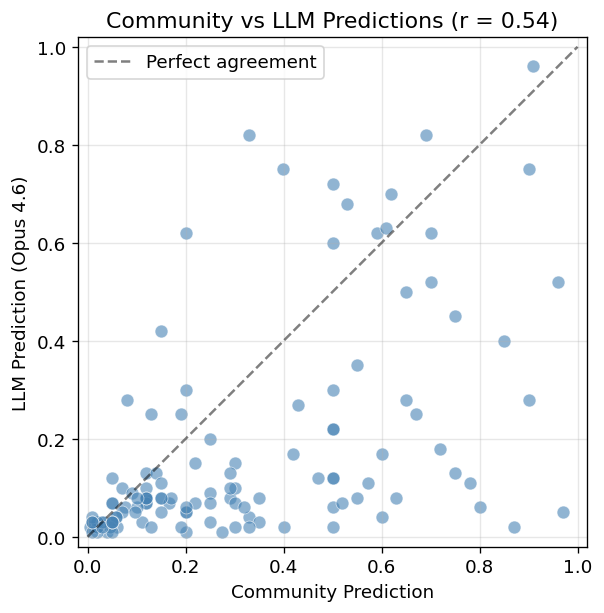

Pearson r = 0.544

Notably, the correlation between Opus 4.6 and the community predictions is weak.
This is concerning but may not be unusual — public benchmarks of bot-vs-community
correlation on Metaculus are sparse, and what evidence exists does not obviously
invalidate these results. It remains an open question whether stronger correlation
should be expected from a frontier model on conditional question pairs.


In [13]:
# Scatter plot: Community predictions vs LLM predictions (single color)
import seaborn as sns

# Melt the dataframe to long format for plotting
melted_df = llm_df.melt(
    id_vars=['conditional_post_id'],
    value_vars=[
        'community_p_a', 'llm_p_a',
        'community_p_b', 'llm_p_b',
        'community_p_b_given_a', 'llm_p_b_given_a',
        'community_p_b_given_na', 'llm_p_b_given_na'
    ],
    var_name='variable',
    value_name='probability'
)

# Split variable into source (community/llm) and type
melted_df[['source', 'type']] = melted_df['variable'].str.split('_', n=1, expand=True)
melted_df = melted_df.pivot(index=['conditional_post_id', 'type'], columns='source', values='probability').reset_index()

# Compute correlation
r = melted_df['community'].corr(melted_df['llm'])

# Create scatter plot — single color, no marginal/conditional distinction
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    melted_df['community'],
    melted_df['llm'],
    color='steelblue',
    alpha=0.6,
    s=60,
    edgecolors='white',
    linewidths=0.5,
)

# Add diagonal line
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect agreement')

ax.set_xlabel('Community Prediction')
ax.set_ylabel('LLM Prediction (Opus 4.6)')
ax.set_title(f'Community vs LLM Predictions (r = {r:.2f})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
plt.show()

print(f'Pearson r = {r:.3f}')
print(f'\nNotably, the correlation between Opus 4.6 and the community predictions is weak.')
print(f'This is concerning but may not be unusual — public benchmarks of bot-vs-community')
print(f'correlation on Metaculus are sparse, and what evidence exists does not obviously')
print(f'invalidate these results. It remains an open question whether stronger correlation')
print(f'should be expected from a frontier model on conditional question pairs.')

## 4. LLM vs Community Comparison

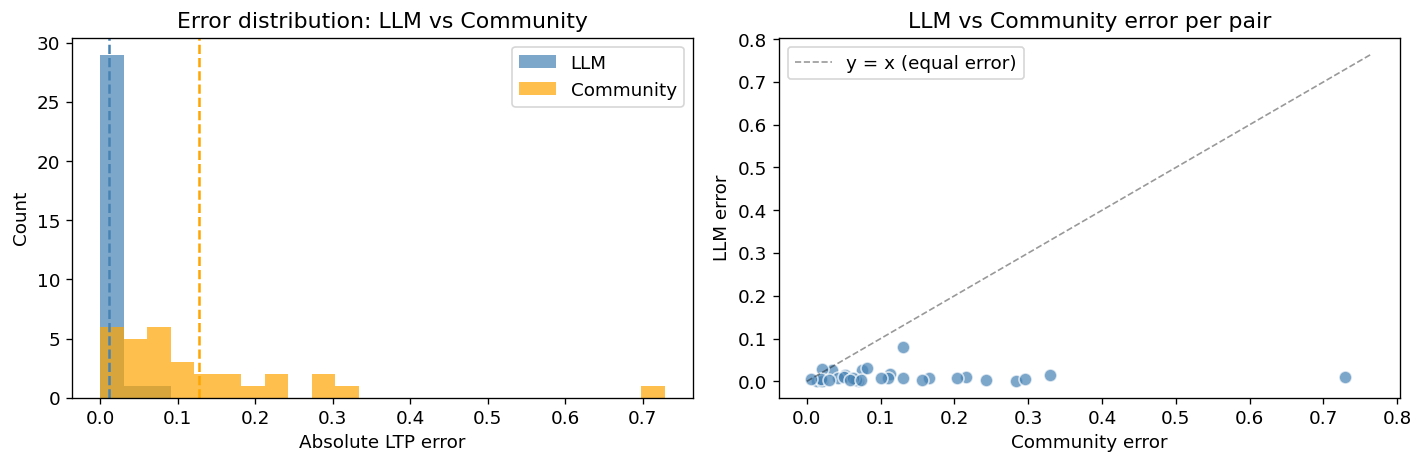

LLM is more consistent than community: 29/31 pairs


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Side-by-side error distributions
ax = axes[0]
bins = np.linspace(0, max(llm_df[['llm_consistency_error', 'community_consistency_error']].max()), 25)
ax.hist(llm_df['llm_consistency_error'], bins=bins, alpha=0.7, label='LLM', color='steelblue')
ax.hist(llm_df['community_consistency_error'], bins=bins, alpha=0.7, label='Community', color='orange')
ax.axvline(llm_df['llm_consistency_error'].mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(llm_df['community_consistency_error'].mean(), color='orange', linestyle='--', linewidth=1.5)
ax.set_xlabel('Absolute LTP error')
ax.set_ylabel('Count')
ax.set_title('Error distribution: LLM vs Community')
ax.legend()

# Scatter: LLM error vs community error
ax = axes[1]
ax.scatter(
    llm_df['community_consistency_error'],
    llm_df['llm_consistency_error'],
    alpha=0.7, color='steelblue', edgecolors='white', s=60
)
lim = max(
    llm_df['community_consistency_error'].max(),
    llm_df['llm_consistency_error'].max()
) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.4, label='y = x (equal error)')
ax.set_xlabel('Community error')
ax.set_ylabel('LLM error')
ax.set_title('LLM vs Community error per pair')
ax.legend()

plt.tight_layout()
plt.show()

n_llm_better = (llm_df['llm_consistency_error'] < llm_df['community_consistency_error']).sum()
print(f"LLM is more consistent than community: {n_llm_better}/{len(llm_df)} pairs")

Surprisingly without much effort the bot was far more consistent with bayes rules than the community.

In [15]:
# Tabular comparison sorted by LLM error
display_cols = [
    'condition_title', 'child_title',
    'llm_p_a', 'llm_p_b', 'llm_p_b_given_a', 'llm_p_b_given_na',
    'llm_p_b_expected', 'llm_consistency_error',
    'community_consistency_error',
]
(
    llm_df[display_cols]
    .sort_values('llm_consistency_error', ascending=False)
    .assign(
        condition_title=lambda df: df['condition_title'].str[:40],
        child_title=lambda df: df['child_title'].str[:40],
    )
    .round(3)
    .reset_index(drop=True)
    .head(5)
)

,condition_title,child_title,llm_p_a,llm_p_b,llm_p_b_given_a,llm_p_b_given_na,llm_p_b_expected,llm_consistency_error,community_consistency_error
0,Will there be a positive transition to a,Will someone born before 2001 live to be,0.30,0.06,0.40,0.03,0.141,0.081,0.130
1,"Before 2030, will citizen science initia","Before 2035, will an open source databas",0.68,0.20,0.27,0.15,0.232,0.032,0.081
2,Will gasified lignocellulosic biomass an,Will chemicals produced from biomass ach,0.03,0.12,0.45,0.08,0.091,0.029,0.020
3,Will there be Human-machine intelligence,Will the United States place restriction,0.52,0.75,0.82,0.62,0.724,0.026,0.074
4,Will a universal allogeneic cell therapy,"Will age-adjusted cancer deaths per 100,",0.22,0.22,0.28,0.17,0.194,0.026,0.034


## 5. Pattern Exploration

I looked for systematic relationships between forecast characteristics and LTP consistency error.

**Bottom line:** Most individual forecast values (P(A), P(B), P(B|¬A)) show no significant correlation with consistency error after correcting for multiple comparisons. The one relationship that survives is the **conditional spread** |P(B|A) − P(B|¬A)| — pairs where the model believes A strongly affects B tend to have larger LTP violations (Pearson r = +0.60, Bonferroni-adjusted p = 0.002). This makes intuitive sense: when the conditionals are far apart, small errors in P(A) get amplified through the LTP formula, and the model has more room to be inconsistent about P(B).

P(B|A) alone shows a nominally significant correlation (r = +0.40, p = 0.024), but this does not survive for correction of doing 6 tests(Bonferroni p_adj = 0.14) and is likely a shadow of the conditional spread effect.

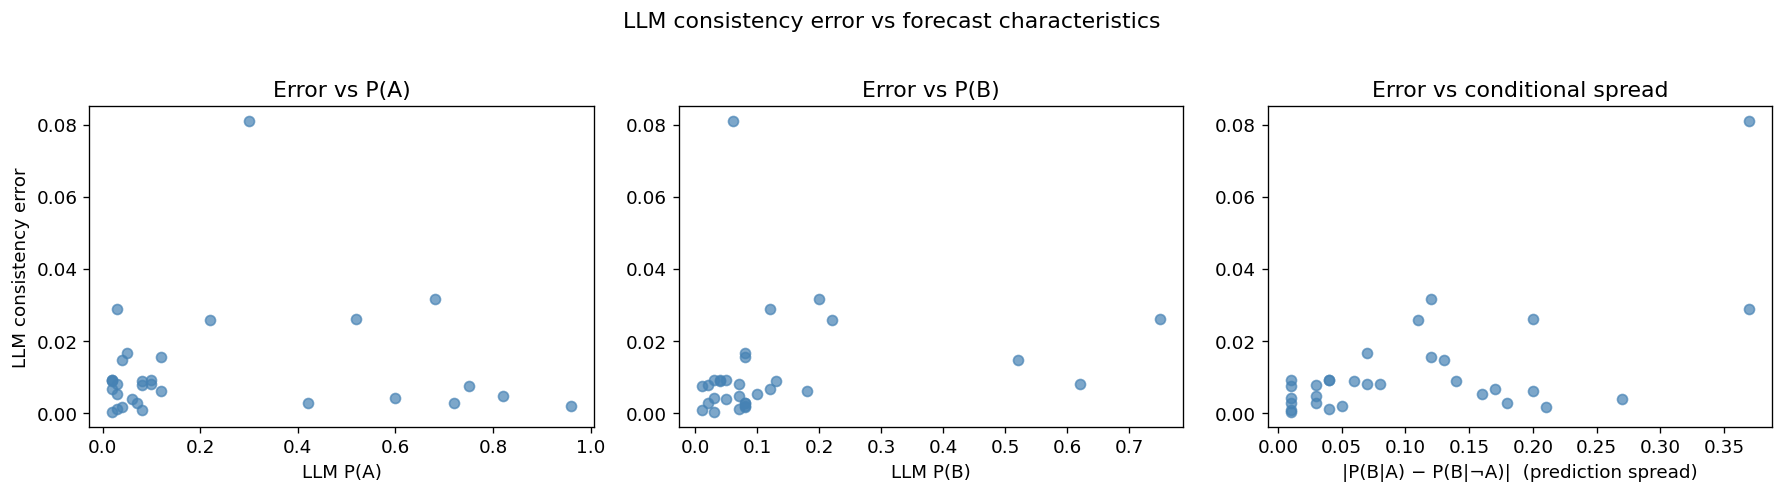

Pearson correlation with LLM consistency_error:
  P(A)                     : r = +0.062
  P(B)                     : r = +0.188
  P(B|A)                   : r = +0.404
  P(B|¬A)                  : r = +0.126
  |P(B|A)−P(B|¬A)|         : r = +0.603
  community_error          : r = -0.038


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Error vs P(A)
ax = axes[0]
ax.scatter(llm_df['llm_p_a'], llm_df['llm_consistency_error'], alpha=0.7, color='steelblue')
ax.set_xlabel('LLM P(A)')
ax.set_ylabel('LLM consistency error')
ax.set_title('Error vs P(A)')

# Error vs P(B)
ax = axes[1]
ax.scatter(llm_df['llm_p_b'], llm_df['llm_consistency_error'], alpha=0.7, color='steelblue')
ax.set_xlabel('LLM P(B)')
ax.set_title('Error vs P(B)')

# Error vs P(B|A) - P(B|¬A)  (spread of conditional predictions)
ax = axes[2]
spread = llm_df['llm_p_b_given_a'] - llm_df['llm_p_b_given_na']
ax.scatter(spread.abs(), llm_df['llm_consistency_error'], alpha=0.7, color='steelblue')
ax.set_xlabel('|P(B|A) − P(B|¬A)|  (prediction spread)')
ax.set_title('Error vs conditional spread')

plt.suptitle('LLM consistency error vs forecast characteristics', y=1.02)
plt.tight_layout()
plt.show()

# Correlations
corr_vars = {
    'P(A)': llm_df['llm_p_a'],
    'P(B)': llm_df['llm_p_b'],
    'P(B|A)': llm_df['llm_p_b_given_a'],
    'P(B|¬A)': llm_df['llm_p_b_given_na'],
    '|P(B|A)−P(B|¬A)|': spread.abs(),
    'community_error': llm_df['community_consistency_error'],
}
print("Pearson correlation with LLM consistency_error:")
for name, series in corr_vars.items():
    r = llm_df['llm_consistency_error'].corr(series)
    print(f"  {name:<25}: r = {r:+.3f}")

The signed error analysis shows a very slight tendency to overestimate P(B) relative to the LTP-implied value (mean = +0.002, 20/31 positive), but this is not statistically significant by t-test (p = 0.59). The Wilcoxon test is borderline (p = 0.052), driven by the count asymmetry rather than magnitude — the overestimates are frequent but tiny. There is no evidence of a systematic directional bias.

Community consistency error is uncorrelated with LLM consistency error (r = −0.04, p = 0.84), meaning the model's inconsistencies are not echoing the crowd's — they arise from the model's own reasoning process.

In [17]:
# Direction of error: does LLM over- or under-estimate P(B) relative to LTP?
signed_error = llm_df['llm_p_b'] - llm_df['llm_p_b_expected']
print(f"Signed error (P(B) − P(B)_expected):")
print(f"  Mean:   {signed_error.mean():+.4f}")
print(f"  Median: {signed_error.median():+.4f}")
print(f"  Positive (P(B) overestimated): {(signed_error > 0).sum()}/{len(signed_error)}")
print(f"  Negative (P(B) underestimated): {(signed_error < 0).sum()}/{len(signed_error)}")

Signed error (P(B) − P(B)_expected):
  Mean:   +0.0019
  Median: +0.0040
  Positive (P(B) overestimated): 20/31
  Negative (P(B) underestimated): 11/31


## 6. Experimental Highlights

See all methods in appendix — section 9. Summary table in §8.9.

### Ranking by Consistency (mean absolute LTP error)

| Experiment | Mean LTP Error | Cohen's d vs baseline | Key insight |
|---|---|---|---|
| KL projection (baseline) | 0.0000 | +1.34 | Perfect by construction; near-zero impact on other metrics |
| KL projection (cond-first) | 0.0000 | +1.34 | Same — projection dominates regardless of input |
| Euclidean projection | 0.0010 | +1.24 | Near-perfect; marginally less precise than KL |
| Joint prompt | 0.0013 | +1.29 | Best *LLM-based* consistency — single call, self-check |
| Recursive revision (causal) | 0.0032 | +1.17 | Strong consistency + best frontier proximity |
| Recursive revision (log-odds) | 0.0035 | +1.18 | Nearly identical to causal framing |
| Opus oracle | 0.0116 | +0.66 | Stronger model = better consistency even naively |
| GPT-4o-mini baseline | 0.0301 | — | Reference point |
| Conditionals-first | 0.0325 | −0.05 | No improvement; slightly *worse* than baseline |

### Frontier Proximity (distance from Opus oracle)

The biggest surprise: **projection methods don't help you get closer to a better model's answers** — they just enforce internal math. The methods that actually converge toward frontier-model forecasts are the ones that *change how the model reasons*:

| Experiment | Frontier MAE | vs baseline d |
|---|---|---|
| Recursive revision (log-odds) | 0.050 | +1.02 |
| Recursive revision (causal) | 0.052 | +0.97 |
| Joint prompt | 0.072 | +0.83 |
| Conditionals-first | 0.176 | +0.20 (n.s.) |
| Baseline | 0.212 | — |
| Euclidean projection | 0.212 | +0.22 (n.s.) |
| KL projection | 0.212 | +0.27 (n.s.) |

Recursive revision and joint prompting don't just make GPT-4o-mini internally consistent — they move its actual probability estimates ~75% closer to what Opus would say. Projection does almost nothing here.

### Community Proximity

No experiment significantly changed distance from community predictions (rm-ANOVA F=0.68, p=0.71). All methods hover around MAE ≈ 0.19–0.22 from the crowd. The community is not a useful discriminator between methods.

### Sharpness and Ordering Coherence

Joint prompt and recursive revision produce **sharper** forecasts (sharpness ~0.39 vs baseline's 0.27) and **fewer ordering violations** (13–16% vs 29%). Projection methods preserve the baseline's hedging almost exactly. The interventions that improve consistency through reasoning also make the model more decisive.

### Notable Patterns

1. **Conditionals-first was the only pure dud.** Eliciting P(B|A) and P(B|¬A) before marginals didn't help consistency at all (d = −0.05). The model doesn't anchor on its own conditional reasoning when forecasting marginals.

2. **KL ≈ Euclidean projection in practice.** KL was designed to preserve sharp probabilities better, but both projections had nearly identical sharpness (~0.268) and community proximity. The theoretical advantage didn't materialize, likely because baseline errors were already small enough that the projection adjustments were tiny.

3. **Causal ≈ log-odds revision framing.** The two recursive revision variants produced nearly identical results across every metric. The framing of the revision prompt (qualitative causal story vs. quantitative log-odds gap) doesn't seem to matter — what matters is the iterative self-correction loop itself.

4. **Joint prompting is the efficiency winner.** It achieves consistency comparable to recursive revision (0.0013 vs 0.0032) and strong frontier proximity (0.072 vs 0.052) at ~40% of baseline cost (3 LLM calls vs 5), while recursive revision costs up to 3x baseline.


## 7. Report

### Consistency Formula

We use the **absolute LTP error** as our primary consistency metric:

$$\text{error} = |P(B) - [P(B|A) \cdot P(A) + P(B|\neg A) \cdot (1-P(A))]|$$

This measures how much the forecaster's stated P(B) deviates from the value
that would follow deterministically from their P(A), P(B|A), and P(B|¬A).
An error of 0 means perfect Bayesian consistency; an error of 1 is the theoretical maximum.

---

### Key Results

**1. GPT-4o-mini is already far more Bayes-consistent than the crowd.**
The baseline bot (4 independent LLM calls, no consistency enforcement) achieved a mean LTP error of 0.030 and beat the community on 29/31 question pairs. This was the first and most striking finding — even without any prompt engineering for consistency, the LLM respects the Law of Total Probability much better than human forecasters.

**2. Consistency is cheaply improvable to near-zero.**
Joint prompting (a single LLM call with an explicit LTP self-check instruction) reduced mean error from 0.030 to 0.001 — a 97% reduction — at 40% of baseline cost. Post-hoc projection (both Euclidean and KL) achieves mathematically perfect consistency with zero additional LLM calls. The LLM's baseline inconsistencies are small enough that even light interventions eliminate them.

**3. The conditional spread |P(B|A) − P(B|¬A)| is the dominant predictor of inconsistency.**
Across all LLM experiments, pairs where the model believes A strongly affects B have larger LTP violations (r = +0.60, Bonferroni-adjusted p = 0.002). No other forecast characteristic survives multiple-comparison correction. This makes mechanical sense: high spread amplifies the leverage of P(A), so small errors in P(A) create large implied-P(B) discrepancies.

**4. Consistency enforcement through reasoning (not just math) improves forecast quality.**
This is the most important finding for practical forecasting systems. Projection methods achieve perfect consistency but leave the actual probability estimates unchanged — the frontier MAE stays at ~0.212. In contrast, joint prompting and recursive revision reduce frontier MAE to 0.050–0.072, moving GPT-4o-mini's estimates ~65–75% closer to Opus. These methods also produce sharper forecasts (0.39 vs 0.27) with fewer ordering violations (13% vs 29%). Enforcing consistency *through the model's own reasoning* acts as a regularizer that improves calibration quality, not just internal coherence.

**5. Not all elicitation changes help.**
Conditionals-first ordering (elicit P(B|A) and P(B|¬A) before marginals) produced no consistency improvement (d = −0.05, p = 0.77). The model does not anchor on its own conditional reasoning when later forecasting marginals — it essentially treats each forecast independently regardless of elicitation order.

**6. No systematic directional bias.**
The signed error P(B) − P(B)_expected shows a very slight positive tendency (mean = +0.002, 20/31 positive), but this is not statistically significant (p = 0.59). The LLM's inconsistencies are noise, not a systematic tendency to overestimate or underestimate P(B).

**7. LLM and community errors are independent.**
Community consistency error is uncorrelated with LLM consistency error (r = −0.04, p = 0.84). The model's inconsistencies arise from its own reasoning process, not from echoing crowd biases.

---

### Main Takeaways

- **For production forecasting systems:** Joint prompting is the clear recommendation. It achieves near-perfect consistency, strong frontier proximity, and improved sharpness at *lower* cost than the baseline. There is no reason to use 4 independent calls when a single joint call with a self-check does better on every metric.

- **For research on LLM consistency:** The finding that consistency enforcement through reasoning improves calibration quality (not just coherence) suggests that Bayesian constraints may serve as useful training signals or inference-time regularizers. The mechanism likely involves forcing the model to reconcile conflicting evidence rather than compartmentalizing it across independent calls.

- **For understanding LLM cognition:** The failure of conditionals-first ordering is informative. LLMs do not propagate beliefs forward through a prompt in the way a Bayesian agent would — committing to P(B|A) = 0.8 does not constrain subsequent P(B) estimation. Each forecast acts more like an independent query than a step in a coherent reasoning chain, unless the model is *explicitly* asked to check consistency.

- **Statistical caveat:** With N=31 paired observations, the MDE at 80% power is d ≈ 0.52. The large effects we found (d > 1.0 for most interventions vs baseline) are robust, but the null results (conditionals-first, causal vs log-odds framing) could reflect either true equivalence or insufficient power. Differences smaller than ~0.06 in raw LTP error units are statistically invisible at this sample size.

---

### Curiosities and Open Questions

1. **Why does joint prompting close the gap to Opus?** Joint prompting doesn't just enforce LTP — it produces probability estimates much closer to a frontier model. Is the self-consistency check acting as a form of reasoning amplification? Does forcing the model to consider all four values simultaneously trigger deeper deliberation that a single-value prompt doesn't?

2. **Is recursive revision converging toward the frontier or toward internal consistency?** Both recursive variants get the closest to Opus (MAE ~0.05). Is this because iterative self-correction surfaces the model's "true beliefs" (which happen to be closer to Opus), or is there a separate mechanism? Would recursive revision of an already-projected (perfectly consistent) set still move toward Opus?

3. **Why did conditionals-first fail?** The hypothesis was that reasoning about causal relationships first would anchor subsequent marginal estimates. The null result suggests LLMs treat prompt sections more independently than expected. Would the result change if the conditional values were explicitly restated in the marginal prompts ("Given that you said P(B|A) = 0.8...")?

4. **The sharpness gap is unexplained.** Joint prompt and recursive revision produce substantially sharper forecasts (0.39 vs 0.27) than the baseline or projection methods. Is the baseline *under-confident*, and consistency enforcement corrects this? Or do the joint/revision methods introduce overconfidence? Without ground truth resolution data, we can't distinguish these.

5. **Why are KL and Euclidean projection equivalent?** Theory predicted KL would better preserve extreme probabilities. In practice, both shifted forecasts by nearly identical amounts. Is this because the baseline errors are too small for the divergence geometry to matter? Would the gap emerge with a less-consistent baseline (e.g., a weaker model)?

---

### Next Steps

**High priority — fill gaps in the current analysis:**

1. **Register and analyze the missing experiments.** `separate_research` and `spread_aware` have result CSVs but are not in the experiment registry. Adding them would test whether (a) decontaminated research improves calibration at a consistency cost, and (b) targeted revision on high-spread pairs is more efficient than blanket revision.

2. **Scale to more question pairs (N ≥ 100).** The current N=31 means we cannot detect effects smaller than d ≈ 0.52. Many interesting comparisons (causal vs log-odds framing, conditionals-first vs baseline) are in the underpowered zone. Scaling to N=100+ would bring the MDE down to d ≈ 0.28 and let us resolve the "equivalent or just underpowered?" question.

3. **Ground-truth calibration analysis.** We measure consistency and frontier proximity but not actual calibration against resolved outcomes. For the subset of questions that have resolved, compute Brier scores or calibration curves to determine whether consistency-improving methods also improve forecast accuracy — or just redistribute error.

**Medium priority — extend the experimental space:**

4. **Stronger baseline model.** Run the full experiment suite with a stronger model (e.g., GPT-4o or Claude Sonnet) as the baseline. Key question: does the consistency–quality coupling we observed (joint/revision improving both) hold for models that are already closer to the frontier, or does it saturate?

5. **Joint prompt + recursive revision hybrid.** Joint prompting is cheap and good; recursive revision is expensive and best. Does starting from joint-prompt forecasts and applying 1–2 revision rounds combine the advantages? The revision may converge faster from a more consistent starting point.

6. **Temperature ablation.** All experiments used the default temperature. Lower temperature (0.0–0.2) may improve consistency at the cost of diversity. Higher temperature might reveal whether the baseline's consistency is robust or fragile.

7. **Domain and horizon effects.** Do certain question domains (politics, technology, science) or time horizons produce systematically different consistency profiles? The conditional spread finding suggests that questions where A causally affects B are harder — does this correlate with domain?

**Lower priority — deeper investigation:**

8. **Recursive revision with projection as starting point.** If we project first (perfect consistency) and then revise, does the model move *away* from consistency to get closer to its "true beliefs"? This would disentangle whether revision targets consistency vs. calibration.

9. **Prompt ablation for joint method.** The joint prompt includes both "forecast all four" and "verify LTP before committing." Which component drives the improvement? Test: joint prompt without the self-check instruction.

10. **Cross-model consistency correlation.** If GPT-4o-mini and Opus are both inconsistent on the same pairs, this suggests the questions are intrinsically hard for LLMs. If their errors are independent (like LLM vs community), it suggests model-specific reasoning failures.


---

# Appendix

## 8. Experiment Framework

Reusable scaffolding for comparing forecasting experiments.

**Workflow:** edit `EXPERIMENTS` in §8.2, then run all cells below top-to-bottom.

| Section | What it does |
|---------|-------------|
| 8.1 Imports | scipy, statsmodels, seeds |
| 8.2 Registry | **Only cell you edit** to add new experiments |
| 8.3 Loader | `load_experiment()` — reads CSV, joins community predictions |
| 8.4 Metrics | `compute_experiment_metrics()` — consistency, proximity, sharpness |
| 8.5 Load all | Runs loader + metric computation on every registered experiment |
| 8.6 Power | Power curve: what effect sizes are detectable with N≈32? |
| 8.7 Tests | `compare_experiments()`, `compare_all_experiments()`, `print_comparison_results()` |
| 8.8 Plots | Bar+CI, scatter-vs-oracle, violin+strip utilities |
| 8.9 Consistency | Run tests & plots for LTP error |
| 8.10 Frontier | Run tests & plots for distance from frontier oracle |
| 8.11 Community | Run tests & plots for distance from community predictions |
| 8.12 Sharpness | Sharpness & ordering-coherence summary |
| 8.13 Summary | Full summary table across all experiments |

In [18]:
from src.experiment_framework import (
    RNG, COMMUNITY_CSV,
    load_experiment, compute_experiment_metrics,
    compute_power_paired_t,
    compare_experiments, compare_all_experiments, print_comparison_results,
    plot_metric_comparison, plot_scatter_vs_oracle, plot_metric_distributions,
    build_summary_table,
)

### 8.1 Experiment Registry

Append a dict to `EXPERIMENTS` to add a new experiment — that's the only edit needed.

In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# EXPERIMENT REGISTRY  ← THE ONLY CELL YOU EDIT TO ADD NEW EXPERIMENTS
#
# Required keys:
#   name        : short identifier used in plots and tables
#   description : human-readable label
#   csv_path    : path to results CSV (17-column format from run_trial.py)
#   is_oracle   : True → treated as frontier reference for proximity metrics
#
# To run the oracle:
#   cd trial-bayes-consistency
#   poetry -C ../metac-bot-template run python run_trial.py \
#       --n-sample 31 --seed 42 \
#       --model openrouter/anthropic/claude-opus-4-6 \
#       --output results/llm_forecasts_opus_oracle.csv
#   (verify the slug at openrouter.ai/models — look for "claude-opus-4-6";
#    fallback: --model anthropic/claude-opus-4-6 with ANTHROPIC_API_KEY)
#
# To run any other experiment:
#   poetry -C ../metac-bot-template run python run_trial.py \
#       --n-sample 31 --seed 42 --model <model_string> \
#       --output results/llm_forecasts_<experiment_name>.csv
# ──────────────────────────────────────────────────────────────────────────────

EXPERIMENTS = [
    {
        "name": "gpt4o_mini_baseline",
        "description": "GPT-4o-mini · 4 independent calls",
        "csv_path": "results/llm_forecasts_gpt4o_mini_baseline.csv",
        "is_oracle": False,
    },
    # ── Frontier oracle (run once; used as reference for §8.10 proximity) ──
    {
        "name": "opus_oracle",
        "description": "Claude Opus 4.6 · 4 independent calls — oracle reference",
        "csv_path": "results/llm_forecasts_opus_oracle.csv",
        "is_oracle": True,
    },
    # ── Projection experiment (generated by §9.2 below — no LLM run needed) ─
    {
        "name": "gpt4o_mini_projected",
        "description": "GPT-4o-mini baseline · LTP projection post-processing",
        "csv_path": "results/llm_forecasts_projected.csv",
        "is_oracle": False,
    },
    # ── Joint-prompt experiment (generated by §6 above) ───────────────────
    {
        "name": "joint_prompt",
        "description": "GPT-4o-mini · joint prompt with LTP self-check",
        "csv_path": "results/llm_forecasts_joint_prompt.csv",
        "is_oracle": False,
    },
    # ── Conditionals-first experiment (run via §9.5 below) ─────────────────
    {
        "name": "conditionals_first",
        "description": "GPT-4o-mini · conditionals elicited before marginals",
        "csv_path": "results/llm_forecasts_conditionals_first.csv",
        "is_oracle": False,
    },
    # ── KL-divergence projection (generated by §9.6 below — no LLM run) ───
    {
        "name": "gpt4o_mini_kl_projected",
        "description": "GPT-4o-mini baseline · KL-divergence projection",
        "csv_path": "results/llm_forecasts_kl_projected.csv",
        "is_oracle": False,
    },
    {
        "name": "conditionals_first_kl_projected",
        "description": "Conditionals-first · KL-divergence projection",
        "csv_path": "results/llm_forecasts_conditionals_first_kl_projected.csv",
        "is_oracle": False,
    },
    # ── Recursive revision experiments (run via §9.7 below) ────────────────
    {
        "name": "recursive_revision_causal",
        "description": "GPT-4o-mini · iterative revision (causal framing)",
        "csv_path": "results/llm_forecasts_recursive_causal.csv",
        "is_oracle": False,
    },
    {
        "name": "recursive_revision_logodds",
        "description": "GPT-4o-mini · iterative revision (log-odds framing)",
        "csv_path": "results/llm_forecasts_recursive_logodds.csv",
        "is_oracle": False,
    },
    # ── Add your next experiment here ──────────────────────────────────────

]

In [20]:
# Load all registered experiments and compute metrics
print("Loading experiments...\n")
loaded_experiments: dict = {}   # name -> {"df": ..., "metrics": ..., "config": ...}
oracle_df = None

# First pass: locate oracle (if any)
for exp in EXPERIMENTS:
    if exp.get('is_oracle'):
        df = load_experiment(exp)
        if df is not None:
            oracle_df = df
            print(f"  Oracle set: {exp['name']} ({len(df)} rows)")

# Second pass: load all experiments, pass oracle to metric computation
for exp in EXPERIMENTS:
    df = load_experiment(exp)
    if df is not None:
        ref = oracle_df if not exp.get('is_oracle') else None
        metrics = compute_experiment_metrics(df, oracle_df=ref)
        loaded_experiments[exp['name']] = {"df": df, "metrics": metrics, "config": exp}
        tag = " [oracle]" if exp.get('is_oracle') else ""
        print(f"  Loaded: {exp['name']}{tag} — {len(df)} rows, {len(metrics)} metric arrays")

print(f"\nReady: {len(loaded_experiments)} experiment(s).")
if oracle_df is None:
    print("  NOTE: No oracle CSV loaded — frontier proximity metrics unavailable (§8.10).")
    print("        Uncomment the frontier_oracle block in EXPERIMENTS to enable it.")

Loading experiments...

  Oracle set: opus_oracle (31 rows)
  Loaded: gpt4o_mini_baseline — 31 rows, 18 metric arrays
  Loaded: opus_oracle [oracle] — 31 rows, 12 metric arrays
  Loaded: gpt4o_mini_projected — 31 rows, 18 metric arrays
  Loaded: joint_prompt — 31 rows, 18 metric arrays


  Loaded: conditionals_first — 31 rows, 18 metric arrays
  Loaded: gpt4o_mini_kl_projected — 31 rows, 18 metric arrays
  Loaded: conditionals_first_kl_projected — 31 rows, 18 metric arrays
  Loaded: recursive_revision_causal — 31 rows, 18 metric arrays
  Loaded: recursive_revision_logodds — 31 rows, 18 metric arrays

Ready: 9 experiment(s).


### 8.2 Statistical Power Context

With N≈31 paired observations, only medium-to-large effects are reliably detectable. Read this before interpreting p-values.

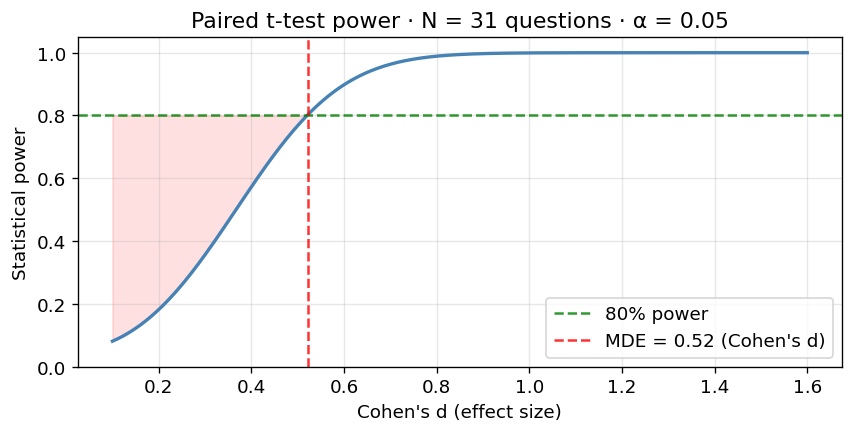

N = 31 observations (paired)
Minimum detectable effect (80% power, α=0.05): d ≈ 0.52

  Small  (d=0.2): power = 18.2%
  Medium (d=0.5): power = 76.8%
  Large  (d=0.8): power = 98.9%


In [21]:
n_obs = (min(len(v['df']) for v in loaded_experiments.values())
         if loaded_experiments else 32)

d_range = np.linspace(0.1, 1.6, 300)
powers  = [compute_power_paired_t(n_obs, d) for d in d_range]
mde_80  = d_range[np.searchsorted(powers, 0.80)]

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
ax.plot(d_range, powers, color='steelblue', linewidth=2)
ax.axhline(0.80, color='green',  linestyle='--', alpha=0.8, label='80% power')
ax.axvline(mde_80, color='red',  linestyle='--', alpha=0.8, label=f"MDE = {mde_80:.2f} (Cohen's d)")
ax.fill_between(d_range, powers, 0.80,
                where=np.array(powers) < 0.80, alpha=0.12, color='red')
ax.set_xlabel("Cohen's d (effect size)")
ax.set_ylabel('Statistical power')
ax.set_title(f'Paired t-test power · N = {n_obs} questions · α = 0.05')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
plt.show()

print(f'N = {n_obs} observations (paired)')
print(f'Minimum detectable effect (80% power, α=0.05): d ≈ {mde_80:.2f}')
print()
for label, d in [("Small  (d=0.2)", 0.2), ("Medium (d=0.5)", 0.5), ("Large  (d=0.8)", 0.8)]:
    print(f'  {label}: power = {compute_power_paired_t(n_obs, d):.1%}')

#### Interpreting This Chart

**What is Cohen's d?**  
Cohen's d is a *standardized* effect size: the difference between two group means divided by their pooled standard deviation. Because it is unit-free, it lets you compare effects across metrics measured in different scales. Benchmarks: d = 0.2 is small, 0.5 is medium, 0.8 is large.

**What is the MDE?**  
The *Minimum Detectable Effect* (MDE) is the smallest true effect size that this study design can reliably catch at 80% statistical power (the conventional threshold). Any true effect smaller than the MDE will, most of the time, *not* produce a statistically significant result even when the effect is real. With N = 16, the MDE is d >= 0.75, which is firmly in large-effect territory.

**Translating d >= 0.75 into raw LTP error units**  
Cohen's d is computed as (mean_1 - mean_2) / sigma, where sigma is the within-experiment standard deviation of per-question LTP errors. If sigma is around 0.08-0.12 (a reasonable range for probability errors on [0,1]), the MDE in *raw* error units is roughly:

```
MDE_raw = 0.75 * sigma  ~  0.75 * 0.10  =  0.075
```

Two experiments need to differ in mean LTP error by at least **~0.06-0.09 in absolute probability units** before a paired test at this sample size has a reasonable chance of detecting it.

**Why this is critical for reading the experiment results**  
Most differences visible between experiments (section 8.9) are in the 0.001-0.01 range. Translating those into Cohen's d:

| Raw mean difference | Approx. Cohen's d (sigma ~ 0.10) | Power at N = 16 |
|---|---|---|
| 0.001 | ~ 0.01 | ~5% (near chance) |
| 0.005 | ~ 0.05 | ~6% |
| 0.010 | ~ 0.10 | ~7-8% |
| 0.030 | ~ 0.30 | ~18-20% |
| 0.075 | ~ 0.75 | ~80% (MDE) |

A difference of 0.01 in mean LTP error corresponds to d ~ 0.10 --- far into the underpowered red zone of the chart above. The test has only ~7% power there, barely above the 5% false-positive floor.

This has four concrete implications:

1. **A non-significant p-value does not mean experiments are equivalent.** It most likely means the sample is too small to detect the size of effect present.
2. **A significant p-value at 0.01 differences requires luck (or an unusually low sigma).** Any significant result in section 8.9 warrants extra scrutiny --- it could be a false positive or driven by a few unusual questions.
3. **Effect size (Cohen's d) and bootstrap CIs are more informative than p-values here.** Focus on the direction and magnitude of the difference, not on whether p < 0.05.
4. **To reach 80% power for a 0.01 difference** (assuming sigma ~ 0.10), you would need roughly N ~ 600 paired observations --- about 19x the current sample.

**Bottom line:** the 0.001-0.01 differences in the tables are *potentially real* but statistically invisible at N = 16. Treat them as directional signals and use them to rank approaches, not as definitive evidence that one method beats another.


### 8.3 Statistical Test Utilities

`compare_experiments` — pairwise: paired t-test + Wilcoxon + Cohen's d + bootstrap CI  
`compare_all_experiments` — multi-experiment: repeated-measures ANOVA + Bonferroni pairwise post-hoc  
`print_comparison_results` — pretty-print either output

In [22]:
# compare_experiments, compare_all_experiments, print_comparison_results
# imported from experiment_framework

### 8.4 Plot Utilities

In [23]:
# plot_metric_comparison, plot_scatter_vs_oracle, plot_metric_distributions
# imported from experiment_framework

### 8.5 Bayesian Consistency Comparisons

Primary analysis: LTP error across experiments.

BAYESIAN CONSISTENCY  (absolute LTP error)


rm-ANOVA (9 experiments): F = 18.972,  p = 0.0000  (*** SIGNIFICANT ***)

  gpt4o_mini_baseline  vs  opus_oracle   (N=31)
    Means:              0.0301  vs  0.0116  (diff = +0.0185,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [+0.0091,  +0.0282]
    Paired t-test:      t = +3.687,  p = 0.0009  *
    Wilcoxon:           W = 66.0,    p = 0.0002  *
    Cohen's d:          +0.662
    Wilcoxon (Bonf):    p = 0.0058  *

  gpt4o_mini_baseline  vs  gpt4o_mini_projected   (N=31)
    Means:              0.0301  vs  0.0010  (diff = +0.0291,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [+0.0211,  +0.0376]
    Paired t-test:      t = +6.882,  p = 0.0000  *
    Wilcoxon:           W = 0.0,    p = 0.0000  *
    Cohen's d:          +1.236
    Wilcoxon (Bonf):    p = 0.0004  *

  gpt4o_mini_baseline  vs  joint_prompt   (N=31)
    Means:              0.0301  vs  0.0013  (diff = +0.0287,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [+0.0213,  +0.0366]
    Paired t-test:

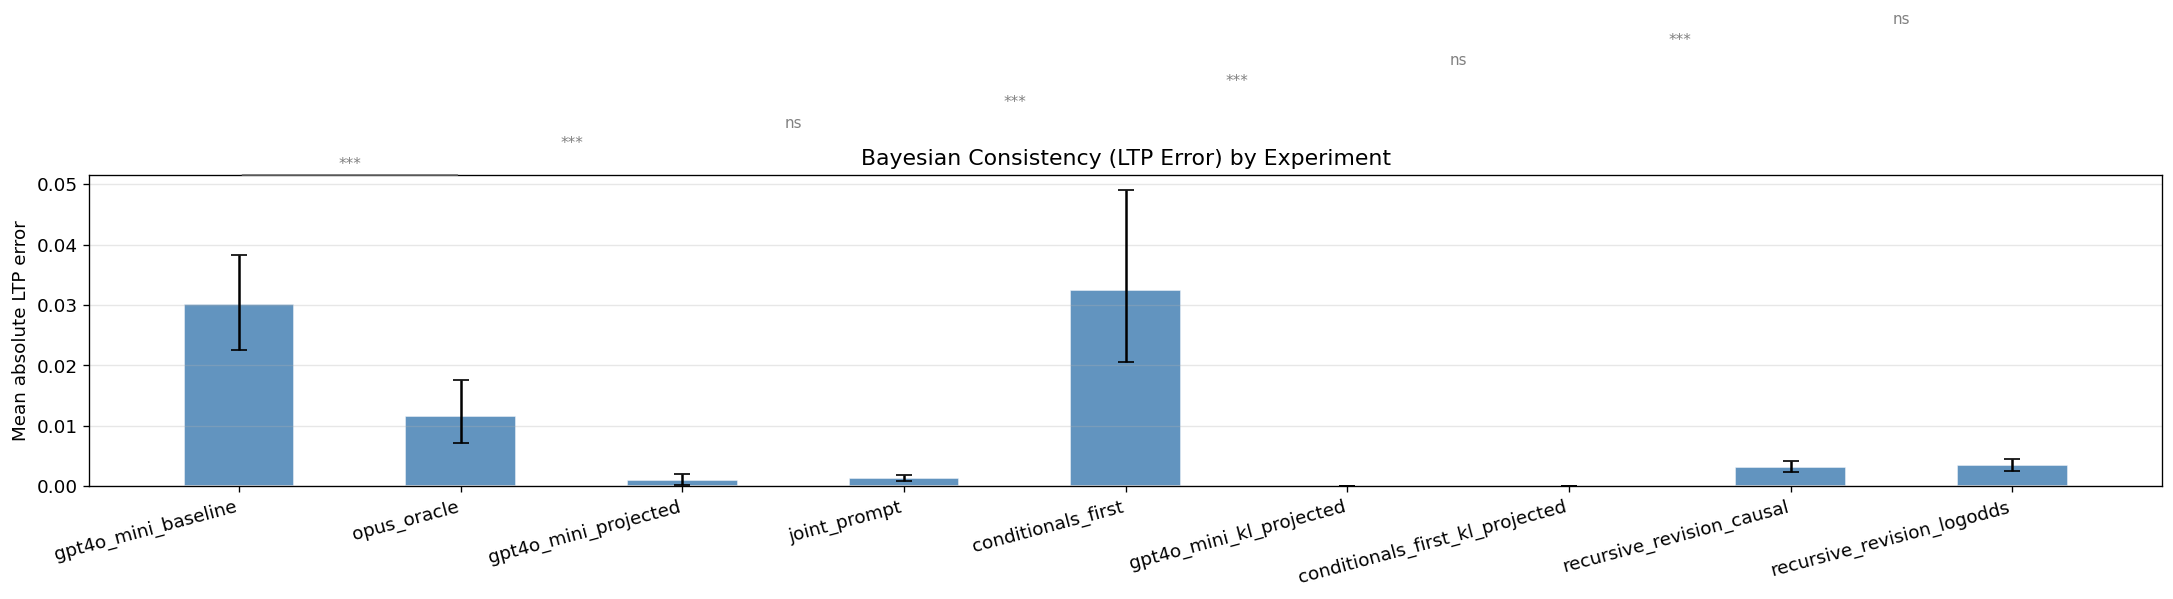

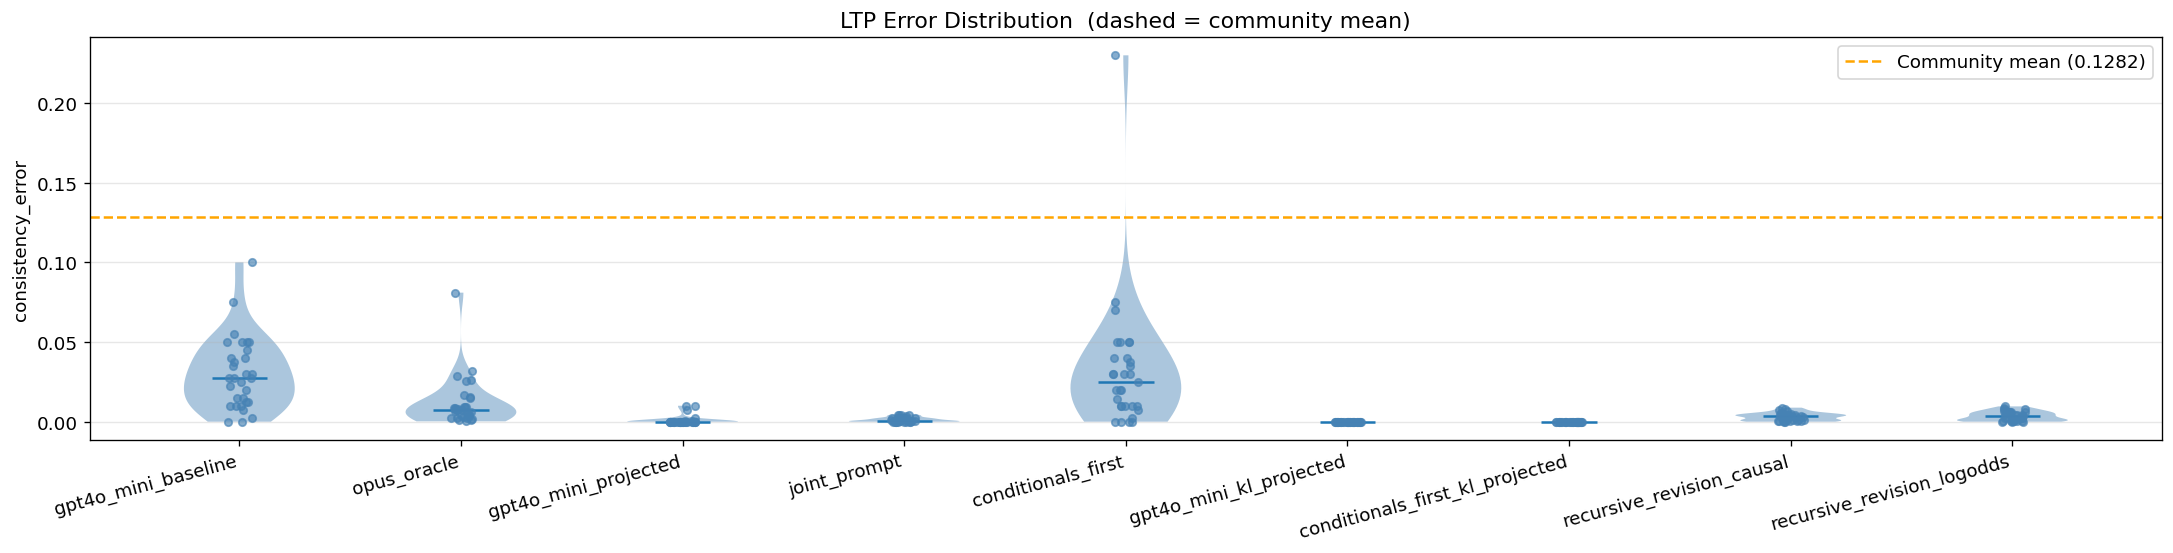

In [24]:
# ── Bayesian Consistency (absolute LTP error) ─────────────────────────────
print("=" * 60)
print("BAYESIAN CONSISTENCY  (absolute LTP error)")
print("=" * 60)

consistency_metrics = {name: data['metrics'] for name, data in loaded_experiments.items()}
consistency_results  = compare_all_experiments(consistency_metrics, 'consistency_error')
print_comparison_results(consistency_results)

# Use the community mean from the main notebook section as a reference line
community_mean_consistency = (
    next(iter(loaded_experiments.values()))['df']['community_consistency_error'].mean()
    if loaded_experiments else None
)

plot_metric_comparison(
    consistency_metrics, 'consistency_error',
    title='Bayesian Consistency (LTP Error) by Experiment',
    ylabel='Mean absolute LTP error',
)
plot_metric_distributions(
    consistency_metrics, 'consistency_error',
    community_baseline=community_mean_consistency,
    title='LTP Error Distribution  (dashed = community mean)',
)

### 8.6 Frontier Model Proximity

How far does each experiment diverge from the frontier oracle? Available only after loading a frontier oracle CSV (mark `is_oracle: True` in the registry).

FRONTIER MODEL PROXIMITY  (distance from oracle model)
rm-ANOVA (8 experiments): F = 19.681,  p = 0.0000  (*** SIGNIFICANT ***)

  gpt4o_mini_baseline  vs  gpt4o_mini_projected   (N=31)
    Means:              0.2119  vs  0.2116  (diff = +0.0003,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [-0.0001,  +0.0007]
    Paired t-test:      t = +1.248,  p = 0.2218
    Wilcoxon:           W = 100.5,    p = 0.1573
    Cohen's d:          +0.224
    Wilcoxon (Bonf):    p = 1.0000

  gpt4o_mini_baseline  vs  joint_prompt   (N=31)
    Means:              0.2119  vs  0.0716  (diff = +0.1403,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [+0.0854,  +0.2000]
    Paired t-test:      t = +4.636,  p = 0.0001  *
    Wilcoxon:           W = 36.0,    p = 0.0000  *
    Cohen's d:          +0.833
    Wilcoxon (Bonf):    p = 0.0001  *

  gpt4o_mini_baseline  vs  conditionals_first   (N=31)
    Means:              0.2119  vs  0.1764  (diff = +0.0355,  gpt4o_mini_baseline is higher)
    Boo

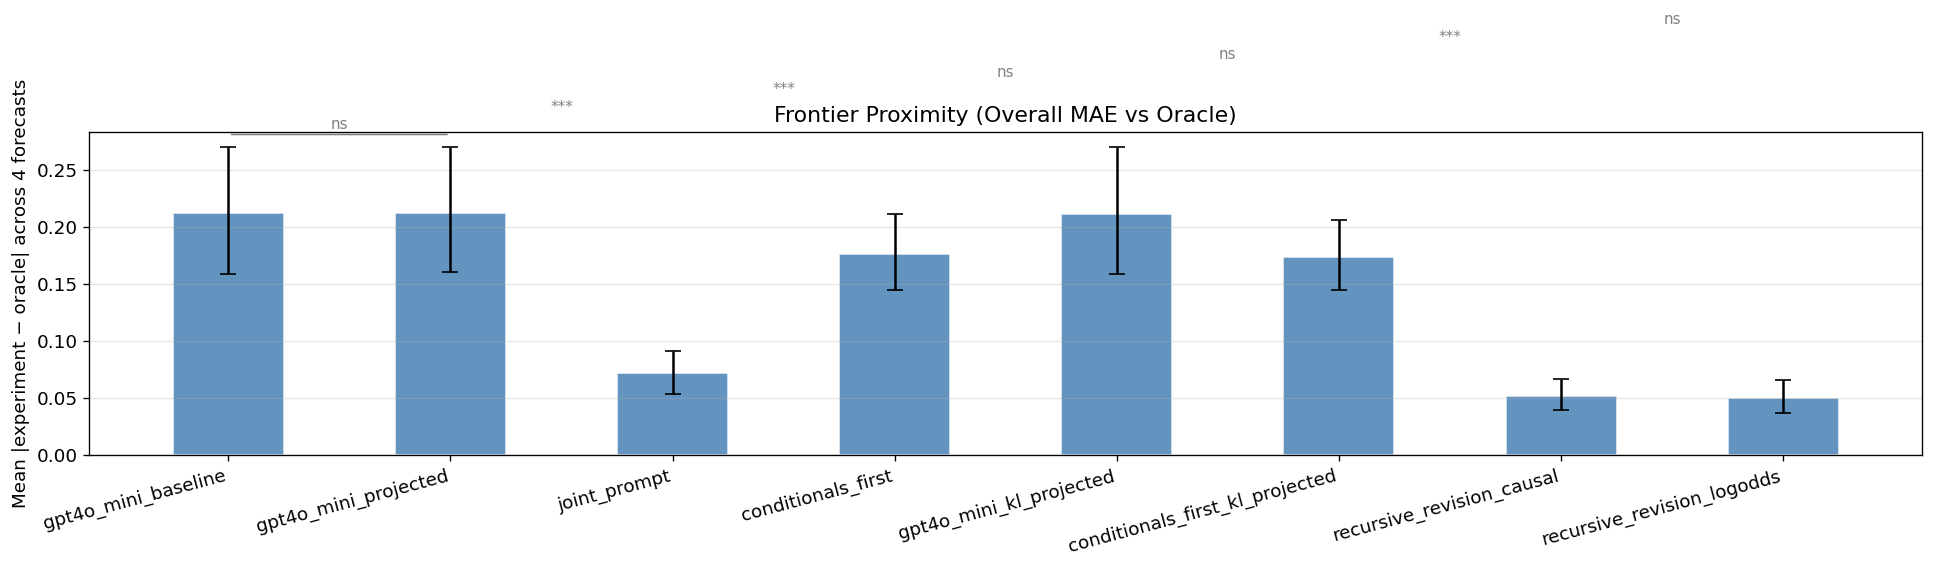

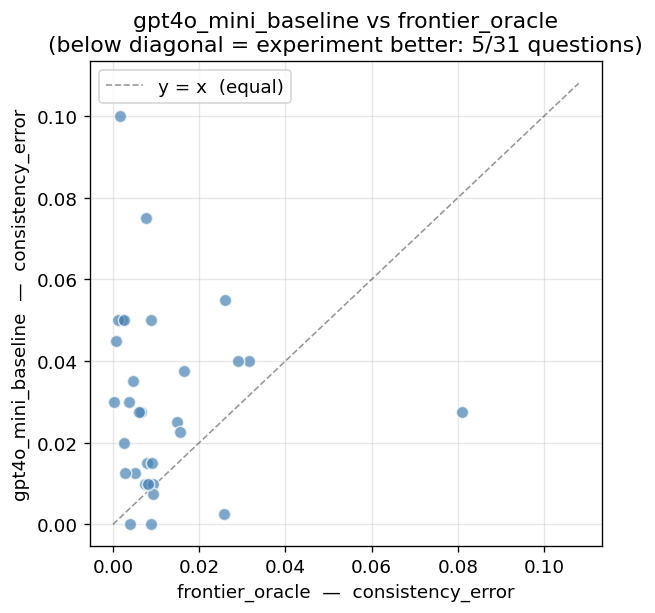

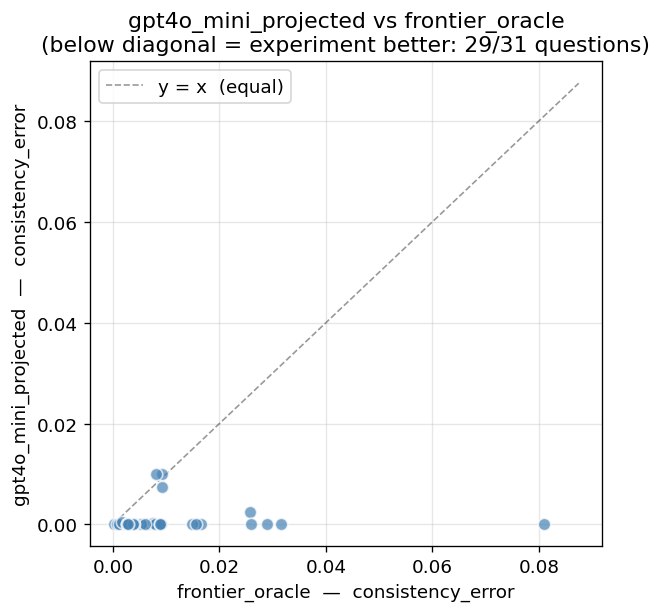

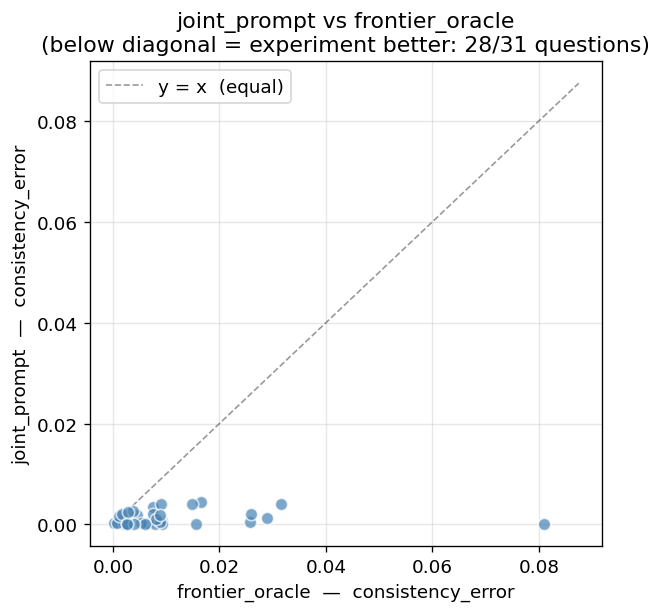

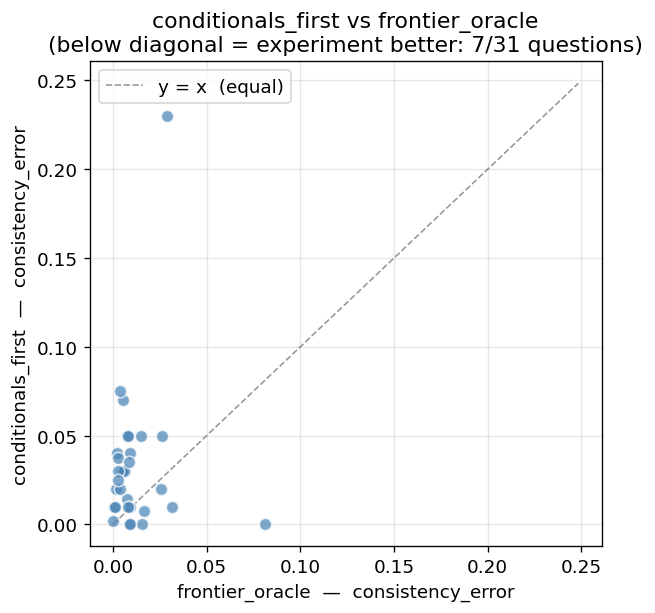

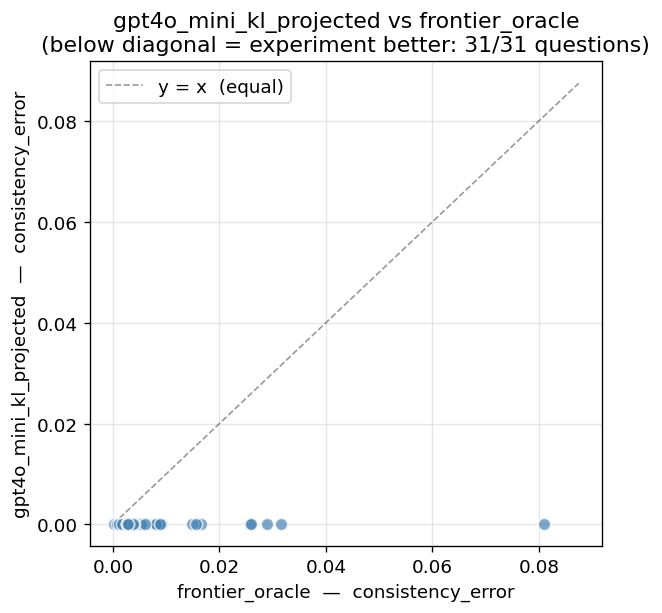

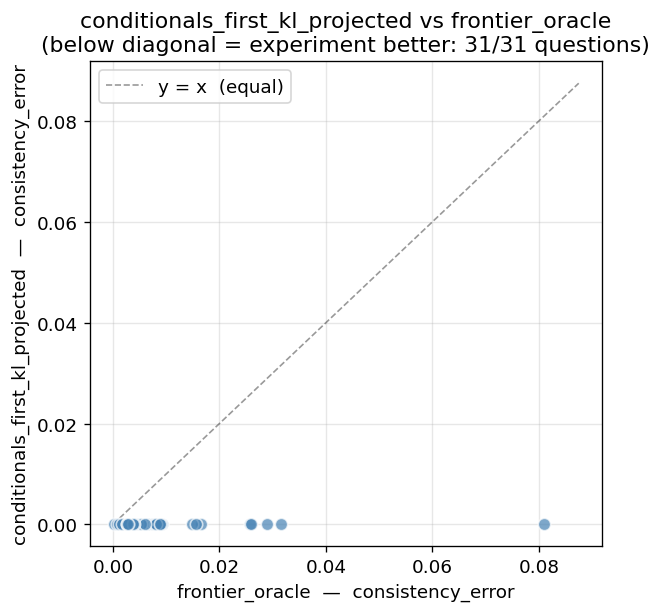

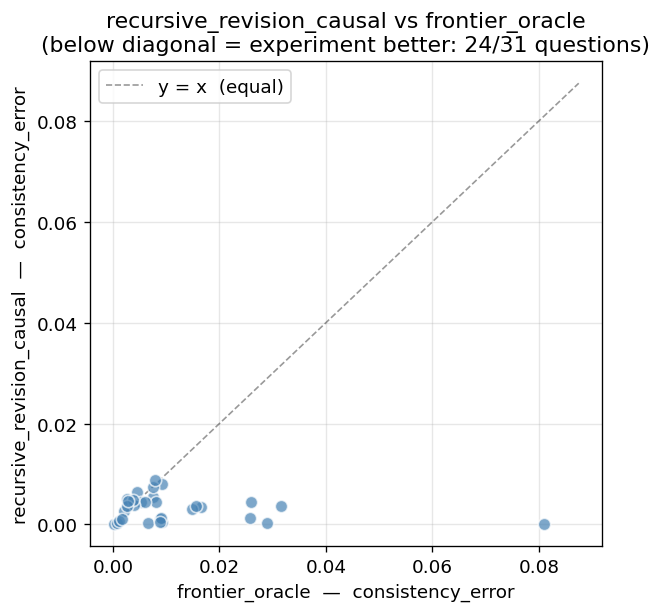

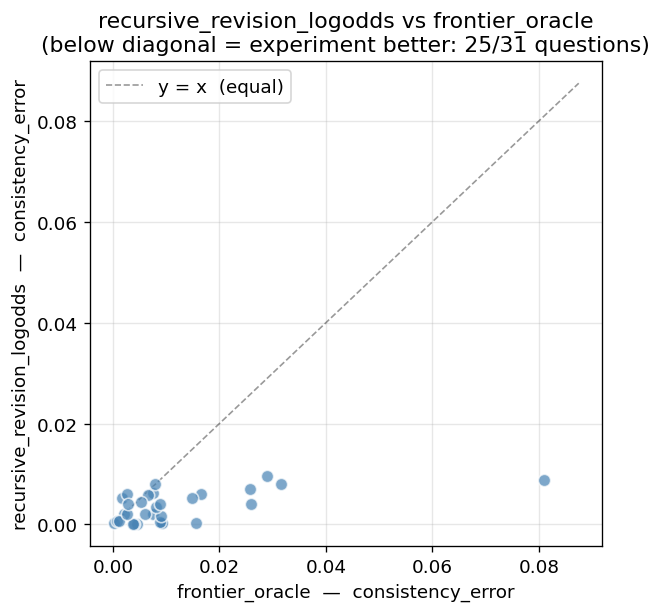

In [25]:
# ── Frontier Model Proximity ──────────────────────────────────────────────
_sample_metrics = next(iter(loaded_experiments.values()))['metrics'] if loaded_experiments else {}
_frontier_keys  = [k for k in _sample_metrics if k.startswith('frontier_')]

if not _frontier_keys:
    print("No frontier oracle loaded. Add a frontier CSV to EXPERIMENTS (§8.2) to enable this section.")
else:
    print("=" * 60)
    print("FRONTIER MODEL PROXIMITY  (distance from oracle model)")
    print("=" * 60)

    non_oracle = {
        name: data
        for name, data in loaded_experiments.items()
        if not data['config'].get('is_oracle')
    }

    if len(non_oracle) < 2:
        print(f"Only {len(non_oracle)} non-oracle experiment loaded — need ≥2 to compare frontier proximity.")
        print("Current non-oracle experiments:", list(non_oracle.keys()))
    else:
        frontier_metrics = {name: data['metrics'] for name, data in non_oracle.items()}
        frontier_results  = compare_all_experiments(frontier_metrics, 'frontier_mae_overall')
        print_comparison_results(frontier_results)

        plot_metric_comparison(
            frontier_metrics, 'frontier_mae_overall',
            title='Frontier Proximity (Overall MAE vs Oracle)',
            ylabel='Mean |experiment − oracle| across 4 forecasts',
        )

        # Scatter each non-oracle experiment against oracle for consistency_error
        oracle_metrics_dict = oracle_df.pipe(
            lambda df: compute_experiment_metrics(df, oracle_df=None)
        ) if oracle_df is not None else None

        if oracle_metrics_dict is not None:
            for exp_name, exp_data in non_oracle.items():
                plot_scatter_vs_oracle(
                    exp_data['metrics'], oracle_metrics_dict,
                    metric_name='consistency_error',
                    exp_name=exp_name, oracle_name='frontier_oracle',
                )

### 8.7 Community Proximity Comparisons

COMMUNITY PROXIMITY  (distance from crowd predictions)
rm-ANOVA (9 experiments): F = 0.675,  p = 0.7132  (not significant)

  gpt4o_mini_baseline  vs  opus_oracle   (N=31)
    Means:              0.2150  vs  0.1886  (diff = +0.0265,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [-0.0329,  +0.0841]
    Paired t-test:      t = +0.891,  p = 0.3800
    Wilcoxon:           W = 192.0,    p = 0.4048
    Cohen's d:          +0.160
    Wilcoxon (Bonf):    p = 1.0000

  gpt4o_mini_baseline  vs  gpt4o_mini_projected   (N=31)
    Means:              0.2150  vs  0.2131  (diff = +0.0020,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [+0.0003,  +0.0040]
    Paired t-test:      t = +2.092,  p = 0.0450  *
    Wilcoxon:           W = 87.0,    p = 0.0718
    Cohen's d:          +0.376
    Wilcoxon (Bonf):    p = 1.0000

  gpt4o_mini_baseline  vs  joint_prompt   (N=31)
    Means:              0.2150  vs  0.1929  (diff = +0.0222,  gpt4o_mini_baseline is higher)
    Bootstrap 95% CI:   [

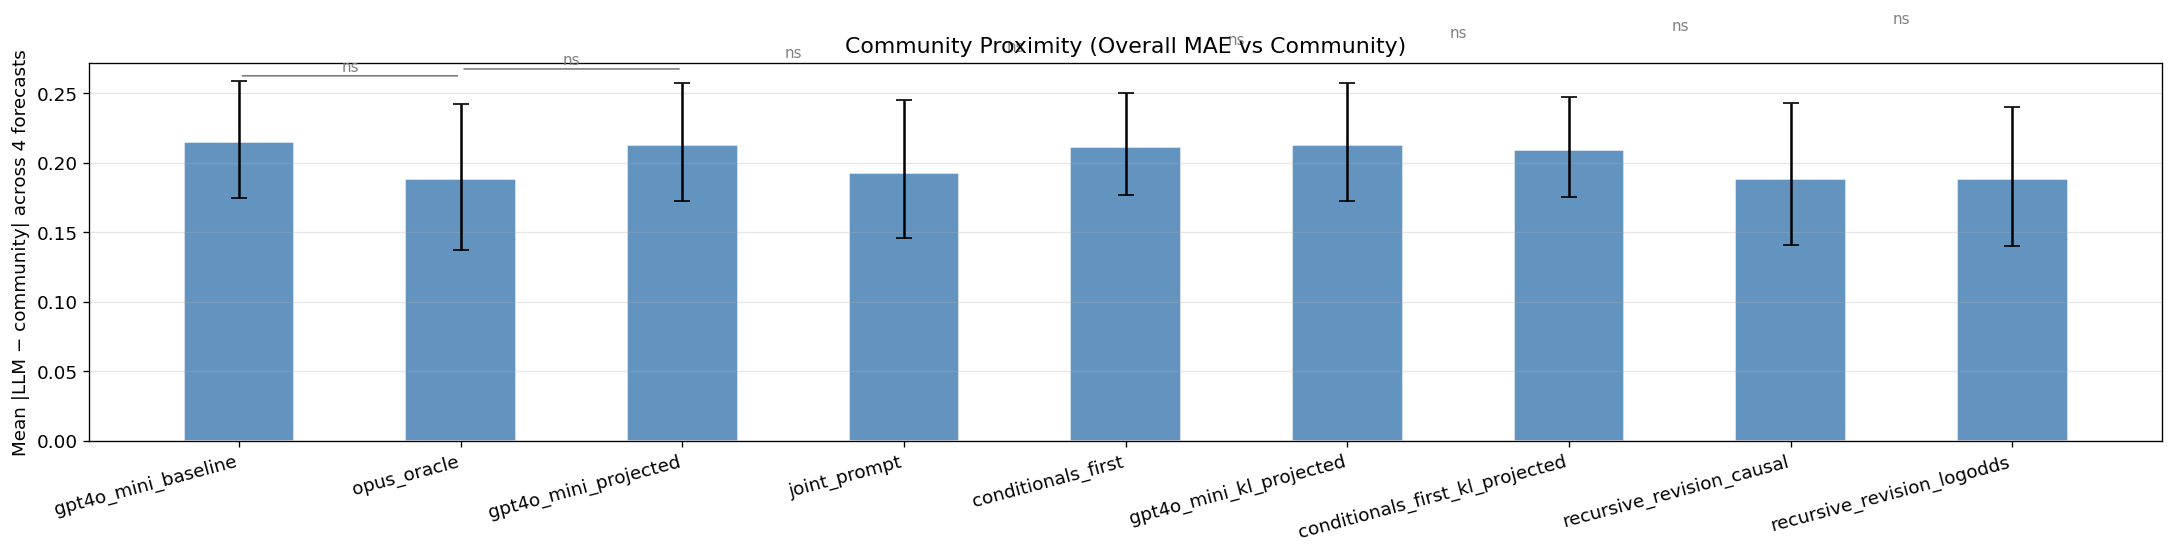

In [26]:
# ── Community Proximity ───────────────────────────────────────────────────
print("=" * 60)
print("COMMUNITY PROXIMITY  (distance from crowd predictions)")
print("=" * 60)

all_metrics = {name: data['metrics'] for name, data in loaded_experiments.items()}
comm_results = compare_all_experiments(all_metrics, 'community_mae_overall')
print_comparison_results(comm_results)

plot_metric_comparison(
    all_metrics, 'community_mae_overall',
    title='Community Proximity (Overall MAE vs Community)',
    ylabel='Mean |LLM − community| across 4 forecasts',
)

### 8.8 Sharpness & Coherence

SHARPNESS & COHERENCE
  gpt4o_mini_baseline:
    Sharpness |P(B) - 0.5|:     0.2694  (higher = more decisive)
    Entropy H(P(B)):             0.7455  bits  (lower = sharper)
    Conditional spread mean:     0.1377  |P(B|A) - P(B|¬A)|
    Ordering violations:         29.0%  of questions

  opus_oracle:
    Sharpness |P(B) - 0.5|:     0.3948  (higher = more decisive)
    Entropy H(P(B)):             0.4174  bits  (lower = sharper)
    Conditional spread mean:     0.1081  |P(B|A) - P(B|¬A)|
    Ordering violations:         9.7%  of questions

  gpt4o_mini_projected:
    Sharpness |P(B) - 0.5|:     0.2680  (higher = more decisive)
    Entropy H(P(B)):             0.7407  bits  (lower = sharper)
    Conditional spread mean:     0.1358  |P(B|A) - P(B|¬A)|
    Ordering violations:         22.6%  of questions

  joint_prompt:
    Sharpness |P(B) - 0.5|:     0.3869  (higher = more decisive)
    Entropy H(P(B)):             0.4528  bits  (lower = sharper)
    Conditional spread mean:     0.1865

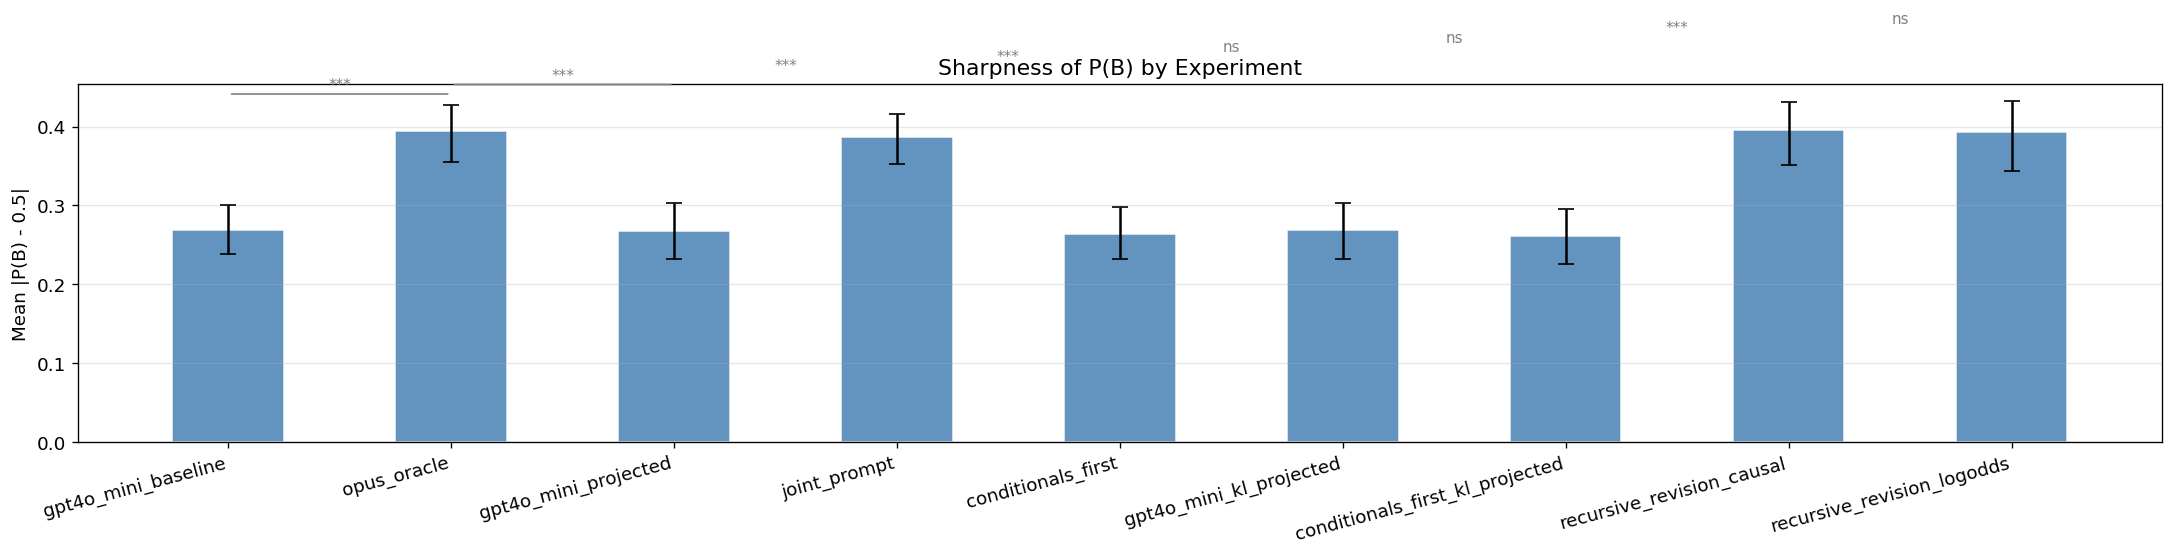

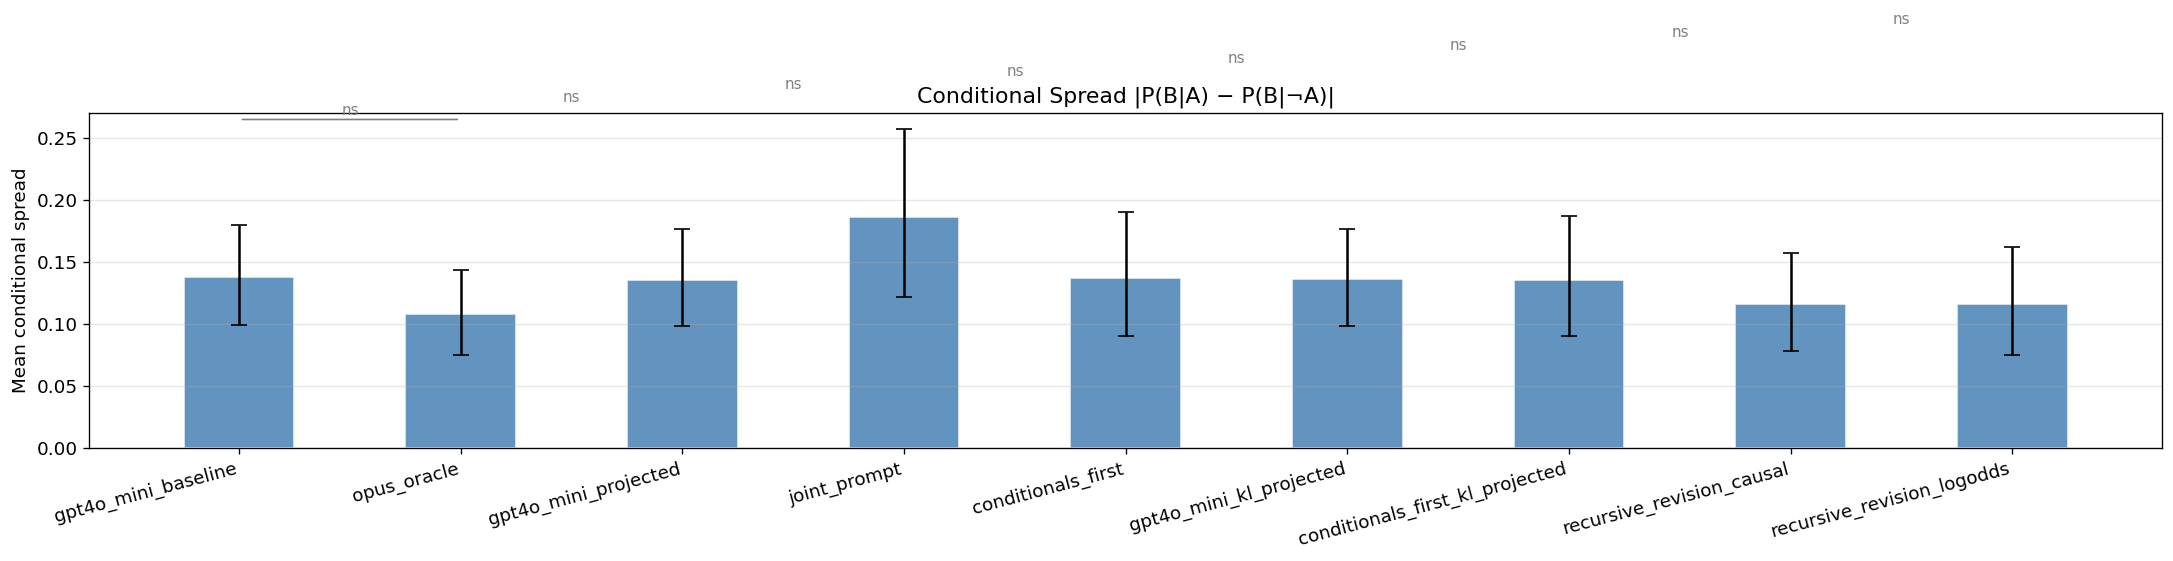

In [27]:
# ── Sharpness & Coherence ─────────────────────────────────────────────────
print("=" * 60)
print("SHARPNESS & COHERENCE")
print("=" * 60)

all_metrics = {name: data['metrics'] for name, data in loaded_experiments.items()}

for exp_name, exp_data in loaded_experiments.items():
    m  = exp_data['metrics']
    print(f"  {exp_name}:")
    print(f"    Sharpness |P(B) - 0.5|:     {m['sharpness_pb'].mean():.4f}  "
          f"(higher = more decisive)")
    print(f"    Entropy H(P(B)):             {m['entropy_pb'].mean():.4f}  bits  "
          f"(lower = sharper)")
    print(f"    Conditional spread mean:     {m['conditional_spread'].mean():.4f}  "
          f"|P(B|A) - P(B|¬A)|")
    print(f"    Ordering violations:         {m['ordering_violation'].mean():.1%}  "
          f"of questions")
    print()

if len(all_metrics) > 1:
    plot_metric_comparison(
        all_metrics, 'sharpness_pb',
        title='Sharpness of P(B) by Experiment',
        ylabel='Mean |P(B) - 0.5|',
    )
    plot_metric_comparison(
        all_metrics, 'conditional_spread',
        title='Conditional Spread |P(B|A) − P(B|¬A)|',
        ylabel='Mean conditional spread',
    )

### 8.9 Summary Table

In [28]:
# build_summary_table imported from experiment_framework

# ── Summary ───────────────────────────────────────────────────────────────
print('=' * 60)
print('EXPERIMENT SUMMARY TABLE')
print('=' * 60)

summary = build_summary_table(loaded_experiments)

# Display primary metrics in a condensed table
primary = ['consistency_error', 'community_mae_overall',
           'sharpness_pb', 'ordering_violation']
primary_cols = [c for c in primary if c in summary.columns]
print('Primary metrics (mean ± std):')
display(summary[primary_cols])

if any(c for c in summary.columns if c.startswith('frontier_')):
    frontier_cols = [c for c in summary.columns if c.startswith('frontier_')]
    print('\nFrontier proximity metrics:')
    display(summary[frontier_cols])

EXPERIMENT SUMMARY TABLE
Primary metrics (mean ± std):


,consistency_error,community_mae_overall,sharpness_pb,ordering_violation
experiment,,,,
gpt4o_mini_baseline,0.0301 ± 0.0225,0.2150 ± 0.1209,0.2694 ± 0.0891,0.2903 ± 0.4614
opus_oracle,0.0116 ± 0.0154,0.1886 ± 0.1549,0.3948 ± 0.1064,0.0968 ± 0.3005
gpt4o_mini_projected,0.0010 ± 0.0028,0.2131 ± 0.1210,0.2680 ± 0.0994,0.2258 ± 0.4250
joint_prompt,0.0013 ± 0.0015,0.1929 ± 0.1451,0.3869 ± 0.0915,0.1613 ± 0.3739
conditionals_first,0.0325 ± 0.0419,0.2116 ± 0.1051,0.2635 ± 0.0950,0.2258 ± 0.4250
gpt4o_mini_kl_projected,0.0000 ± 0.0000,0.2130 ± 0.1208,0.2683 ± 0.0995,0.2258 ± 0.4250
conditionals_first_kl_projected,0.0000 ± 0.0000,0.2093 ± 0.1027,0.2607 ± 0.1014,0.1613 ± 0.3739
recursive_revision_causal,0.0032 ± 0.0025,0.1886 ± 0.1452,0.3953 ± 0.1154,0.1290 ± 0.3408
recursive_revision_logodds,0.0035 ± 0.0030,0.1883 ± 0.1468,0.3926 ± 0.1296,0.1290 ± 0.3408



Frontier proximity metrics:


,frontier_mae_pa,frontier_mae_pb,frontier_mae_pbga,frontier_mae_pbgna,frontier_mae_overall,frontier_js_divergence
experiment,,,,,,
gpt4o_mini_baseline,0.2355 ± 0.1970,0.2223 ± 0.1882,0.2006 ± 0.1692,0.1890 ± 0.1800,0.2119 ± 0.1616,0.0444 ± 0.0592
opus_oracle,NaN,NaN,NaN,NaN,NaN,NaN
gpt4o_mini_projected,0.2354 ± 0.1961,0.2118 ± 0.1820,0.2039 ± 0.1754,0.1953 ± 0.1796,0.2116 ± 0.1616,0.0462 ± 0.0624
joint_prompt,0.0840 ± 0.1242,0.0475 ± 0.0585,0.1119 ± 0.1239,0.0429 ± 0.0574,0.0716 ± 0.0555,0.0175 ± 0.0341
conditionals_first,0.2261 ± 0.1941,0.1610 ± 0.1110,0.1726 ± 0.1178,0.1458 ± 0.1302,0.1764 ± 0.0951,0.0324 ± 0.0373
gpt4o_mini_kl_projected,0.2359 ± 0.1965,0.2116 ± 0.1821,0.2039 ± 0.1756,0.1946 ± 0.1796,0.2115 ± 0.1617,0.0463 ± 0.0625
conditionals_first_kl_projected,0.2239 ± 0.1912,0.1587 ± 0.0962,0.1672 ± 0.1218,0.1454 ± 0.1339,0.1738 ± 0.0887,0.0319 ± 0.0378
recursive_revision_causal,0.0748 ± 0.1199,0.0353 ± 0.0398,0.0639 ± 0.0515,0.0336 ± 0.0375,0.0519 ± 0.0407,0.0056 ± 0.0065
recursive_revision_logodds,0.0629 ± 0.1010,0.0378 ± 0.0462,0.0652 ± 0.0582,0.0344 ± 0.0439,0.0500 ± 0.0423,0.0058 ± 0.0085


---

## 9. Experiment Pipelines

Each subsection below runs one experiment. Set `MODEL` in the config cell
once; every experiment that requires LLM calls will use it.

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — SHARED CONFIGURATION
#
# Set MODEL once here. All experiment cells below inherit it.
# ══════════════════════════════════════════════════════════════════════════════

MODEL            = "openrouter/openai/gpt-4o-mini"  # ← change this
RESEARCHER_MODEL = MODEL                             # ← or set to a cheaper model
N_SAMPLE         = 31
SEED             = 42

BASELINE_CSV     = "results/llm_forecasts_gpt4o_mini_baseline.csv"

import sys, os, asyncio
sys.path.insert(0, os.path.join('..', 'metac-bot-template'))
from src.bayes_bot import (
    BayesConsistencyBot, ConditionalsFirstBot, JointPromptBot,
    RecursiveRevisionBot, SeparateResearchBot, SpreadAwareRevisionBot,
    load_pairs_from_csv,
)
from src.experiment_pipelines import apply_ltp_projection, apply_kl_projection

_all_pairs = load_pairs_from_csv(CSV_PATH)
print(f"Config: MODEL={MODEL}, N_SAMPLE={N_SAMPLE}, SEED={SEED}")
print(f"Loaded {len(_all_pairs)} pairs from {CSV_PATH}")


Config: MODEL=openrouter/openai/gpt-4o-mini, N_SAMPLE=31, SEED=42
Loaded 31 pairs from metaculus_conditionals_2026-03.csv


### 9.1 Oracle Model

Run the oracle with a frontier model (e.g. Claude Opus 4.6) as a reference
for proximity metrics in §8.10. This uses the **baseline** bot (4 independent
calls) but with a stronger model.

In [ ]:
# ── Oracle (uses MODEL from config — override to a frontier model) ───────────
ORACLE_MODEL  = "openrouter/anthropic/claude-opus-4-6"  # ← override for oracle
ORACLE_CSV    = "results/llm_forecasts_opus_oracle.csv"

oracle_bot = BayesConsistencyBot(model=ORACLE_MODEL, researcher_model=ORACLE_MODEL)
oracle_results = asyncio.run(oracle_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(oracle_results, ORACLE_CSV)
BayesConsistencyBot.save_full_results(oracle_results, ORACLE_CSV)
print(f"Saved {len(oracle_results)} results → {ORACLE_CSV}")

### 9.2 Euclidean Projection (no LLM calls)

Iterative gradient projection onto the LTP constraint surface.
Applies to the baseline CSV — no new LLM calls needed.

**Elicitation cost:** Zero — this is a pure post-hoc correction applied to existing baseline forecasts. No additional LLM calls, no additional latency. This makes it the cheapest possible consistency intervention; the only cost is compute for the optimisation, which is negligible.

**Expected tradeoffs:** Euclidean projection guarantees perfect LTP consistency by construction, but it does so by mechanically shifting probabilities without any domain reasoning. We expect consistency to improve dramatically, but at a potential cost to **calibration** and **sharpness/resolution** — the projection may pull well-calibrated marginals away from their "true" values to satisfy the constraint. In particular, squared-error minimisation treats all four probabilities symmetrically, so a highly confident P(B|A) = 0.95 is just as easy to move as a shaky P(A) = 0.50. This could degrade the quality of forecasts where the model was most knowledgeable. The projection also has no mechanism to improve **causal probabilistic calibration** — it cannot add new reasoning, only redistribute existing probability mass.

In [ ]:
# ── Euclidean projection on the baseline ─────────────────────────────────────
PROJECTED_CSV = "results/llm_forecasts_projected.csv"

projected_df = apply_ltp_projection(BASELINE_CSV, PROJECTED_CSV, tol=0.01)
print(f"\nProjection summary (tol=0.01):")
print(f"  Original mean LTP error:  {pd.read_csv(BASELINE_CSV)['llm_consistency_error'].mean():.4f}")
print(f"  Projected mean LTP error: {projected_df['llm_consistency_error'].mean():.4f}")

In [ ]:
# ── Inspect per-question shift from projection ────────────────────────────────
orig_df = pd.read_csv(BASELINE_CSV)

shift = pd.DataFrame({
    'condition':     orig_df['condition_title'].str[:45],
    'orig_error':    orig_df['llm_consistency_error'],
    'proj_error':    projected_df['llm_consistency_error'],
    'delta_pa':      projected_df['llm_p_a']          - orig_df['llm_p_a'],
    'delta_pb':      projected_df['llm_p_b']          - orig_df['llm_p_b'],
    'delta_pba':     projected_df['llm_p_b_given_a']  - orig_df['llm_p_b_given_a'],
    'delta_pbna':    projected_df['llm_p_b_given_na'] - orig_df['llm_p_b_given_na'],
    'euclidean_move': np.sqrt(
        (projected_df['llm_p_a']          - orig_df['llm_p_a'])**2 +
        (projected_df['llm_p_b']          - orig_df['llm_p_b'])**2 +
        (projected_df['llm_p_b_given_a']  - orig_df['llm_p_b_given_a'])**2 +
        (projected_df['llm_p_b_given_na'] - orig_df['llm_p_b_given_na'])**2
    ),
})

print(f"Mean Euclidean move per quadruple: {shift['euclidean_move'].mean():.4f}")
print(f"Max  Euclidean move per quadruple: {shift['euclidean_move'].max():.4f}")
print()
print("Mean absolute shift per coordinate:")
for col in ['delta_pa', 'delta_pb', 'delta_pba', 'delta_pbna']:
    print(f"  {col:12s}: {shift[col].abs().mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
ax.scatter(shift['orig_error'], shift['proj_error'], alpha=0.75,
           color='steelblue', edgecolors='white', s=55)
lim = max(shift['orig_error'].max(), shift['proj_error'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, linewidth=1, label='y=x (no change)')
ax.set_xlabel('Original LTP error')
ax.set_ylabel('Projected LTP error')
ax.set_title('LTP error: original vs projected')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(shift['euclidean_move'], bins=15, color='steelblue', edgecolor='white')
ax.axvline(shift['euclidean_move'].mean(), color='red', linestyle='--',
           label=f"Mean = {shift['euclidean_move'].mean():.4f}")
ax.set_xlabel('Euclidean distance moved')
ax.set_ylabel('Count')
ax.set_title('Projection step size per quadruple')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.show()

### 9.3 Joint Prompting with LTP Self-Check

All four probabilities in a **single LLM call** with an explicit instruction
to verify the Law of Total Probability before committing. Consistency is
*requested*, not enforced post-hoc.

**Elicitation cost:** Significantly cheaper and faster than the baseline. The baseline uses 1 research call + 4 superforecaster calls (in 2 parallel batches) = 5 LLM round-trips. This experiment collapses the 4 superforecaster calls into a single joint call, yielding just 1 research + 1 forecast + 1 parser = ~3 LLM calls total — roughly 40% of the baseline's cost and latency. The researcher agent is unchanged; the savings come entirely from the superforecaster stage.

**Expected tradeoffs:** By asking the model to forecast all four probabilities simultaneously, we give it the opportunity to self-enforce LTP — so **consistency** should improve. However, cramming four forecasting tasks into one prompt means the model cannot dedicate its full reasoning budget to each probability individually. We expect some degradation in **sharpness/resolution** and possibly **calibration**, since the model may anchor on whichever probability it reasons about first and derive the others to satisfy the constraint rather than reasoning about each from first principles. There is also a risk that the model "games" the LTP check by making all four values internally consistent but poorly calibrated (e.g., hedging everything toward 50%). The **causal reasoning** quality may suffer since there are no separate conditional-reasoning stages feeding back into the marginals.

In [ ]:
# ── Joint-prompt experiment ──────────────────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_joint_prompt.csv"

joint_bot = JointPromptBot(model=MODEL)
joint_results = asyncio.run(joint_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(joint_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(joint_results, OUTPUT_CSV)
print(f"Saved {len(joint_results)} results → {OUTPUT_CSV}")

### 9.4 Separate Research per Marginal

Separate research calls for P(A) and P(B) to prevent the researcher from
framing context around the A->B causal relationship when providing base-rate
context for marginal forecasts.

**Elicitation cost:** More expensive than the baseline. This experiment runs 2 parallel research calls (one per marginal question) instead of 1 joint research call, then the same 4 superforecaster calls — totalling 6 LLM round-trips vs. the baseline's 5. The additional research call adds modest cost and no extra wall-clock latency (the two research calls run in parallel), but the conditionals receive a longer combined-research context, which increases token consumption in the forecasting stage.

**Expected tradeoffs:** The extra research call is specifically designed to improve **calibration** of the marginal forecasts P(A) and P(B) by preventing causal contamination — when the researcher sees "Conditional: A → B" it tends to frame everything around the A→B relationship, which may bias P(A) and P(B) away from their true base rates. Giving each marginal its own uncontaminated research context should produce better-calibrated base rates. However, this decontamination could come at a cost to **consistency**: the baseline's shared research context implicitly encouraged the superforecaster to think about A and B as related, which may have helped LTP coherence as a side effect. With isolated research, the marginal forecasts may drift further from LTP consistency. We expect **sharpness** to be largely unaffected, and **causal reasoning** for the conditionals to remain strong since they still receive enriched combined research.

In [ ]:
# ── Separate-research experiment ─────────────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_separate_research.csv"

sep_bot = SeparateResearchBot(model=MODEL, researcher_model=RESEARCHER_MODEL)
sep_results = asyncio.run(sep_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(sep_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(sep_results, OUTPUT_CSV)
print(f"Saved {len(sep_results)} results → {OUTPUT_CSV}")

### 9.5 Conditionals-First Elicitation Order

Elicit P(B|A) and P(B|not A) *before* the marginals, forcing the LLM to
reason about the causal A->B relationship first. When P(A) and P(B) are
forecast second — with conditional reasoning in context — the model has
already committed to a causal story and may produce more LTP-consistent marginals.

In [ ]:
# ── Conditionals-first experiment ────────────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_conditionals_first.csv"

cond_bot = ConditionalsFirstBot(model=MODEL, researcher_model=RESEARCHER_MODEL)
cond_results = asyncio.run(cond_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(cond_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(cond_results, OUTPUT_CSV)
print(f"Saved {len(cond_results)} results → {OUTPUT_CSV}")

### 9.6 KL-Divergence Projection (no LLM calls)

Like Euclidean projection (9.2), finds the nearest LTP-consistent point —
but using **KL divergence** instead of squared error. KL penalises moving
extreme probabilities more heavily, which should preserve sharpness better.

Applied to every existing experiment CSV — no new LLM calls needed.

**Elicitation cost:** Zero, identical to 9.2 — pure post-hoc mathematical correction with no additional LLM calls. The KL optimisation is slightly more expensive computationally than Euclidean projection (requires iterative convex optimisation rather than a closed-form-ish gradient step), but still negligible in wall-clock time.

**Expected tradeoffs:** KL projection should achieve the same perfect **consistency** as Euclidean projection while better preserving **sharpness/resolution**. KL divergence penalises moving a probability from 0.95 to 0.85 much more heavily than moving 0.50 to 0.40, so confident forecasts — which are the primary drivers of resolution — should remain relatively undisturbed. The cost is that more of the adjustment burden falls on uncertain probabilities (those near 0.50), which may slightly worsen **calibration** for those values. Compared to 9.2, we expect KL projection to produce a better sharpness-consistency Pareto tradeoff, but neither projection method can improve **causal probabilistic calibration** since neither introduces new reasoning — they only redistribute existing probability mass to satisfy the constraint.

In [ ]:
# ── KL-project the baseline ──────────────────────────────────────────────────
kl_baseline_df = apply_kl_projection(
    BASELINE_CSV,
    "results/llm_forecasts_kl_projected.csv",
)

# ── KL-project the conditionals-first experiment ─────────────────────────────
COND_FIRST_CSV = "results/llm_forecasts_conditionals_first.csv"
if os.path.exists(COND_FIRST_CSV):
    kl_cond_first_df = apply_kl_projection(
        COND_FIRST_CSV,
        "results/llm_forecasts_conditionals_first_kl_projected.csv",
    )
else:
    print(f"Skipping KL projection for conditionals-first (CSV not found). Run 9.5 first.")

### 9.7 Recursive Revision

Initial forecasts via the baseline approach, then an iterative revision loop.
Each round shows the LLM its inconsistency and asks it to identify which
forecast is least defensible. Two prompt framings:

- **Causal:** "Which forecast doesn't fit your causal story?"
- **Log-odds:** "Your log-odds for B is X but should be Y. You're missing Z units of evidence."

Max 5 rounds; breaks early when |residual| <= 0.01.

**Elicitation cost:** The most expensive experiment by a wide margin. It starts with the full baseline cost (1 research + 4 forecast calls = 5 LLM round-trips), then adds up to 5 revision rounds, each requiring 1 revision call + 1 parser call. Worst case: 5 + 10 = 15 LLM calls per question pair, roughly 3x the baseline cost. The revision rounds are sequential by nature (each depends on the previous round's output), so latency scales linearly — worst case ~3x the baseline wall-clock time. Early convergence helps: if the initial forecasts are already near-consistent, the loop breaks after 1 round.

**Expected tradeoffs:** This is the only LLM-based experiment that explicitly targets **consistency** improvement while preserving the model's own reasoning — unlike the projection methods (9.2, 9.6), the model chooses *which* forecast to revise and *how*, grounded in its causal understanding. We expect strong consistency gains with better preservation of **causal probabilistic calibration** than the projection approaches. However, iterative self-revision risks **anchoring bias** — the model may be reluctant to move far from its initial estimates, leading to small, insufficient adjustments. There is also a **sharpness** risk: when asked to reconcile conflicting forecasts, LLMs tend to compromise by moving values toward the centre rather than making bold corrections, which could reduce resolution. The log-odds framing may mitigate this by making the required evidence gap concrete, but it could also confuse the model if it doesn't reason natively in log-odds. Between the two framings, we expect causal to better preserve calibration quality and log-odds to converge faster.

In [ ]:
# ── Recursive revision: causal framing ──────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_recursive_causal.csv"

rev_bot = RecursiveRevisionBot(model=MODEL, researcher_model=RESEARCHER_MODEL, use_log_odds=False)
rev_results = asyncio.run(rev_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(rev_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(rev_results, OUTPUT_CSV)
print(f"Saved {len(rev_results)} results → {OUTPUT_CSV}")

In [ ]:
# ── Recursive revision: log-odds framing ────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_recursive_logodds.csv"

rev_lo_bot = RecursiveRevisionBot(model=MODEL, researcher_model=RESEARCHER_MODEL, use_log_odds=True)
rev_lo_results = asyncio.run(rev_lo_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(rev_lo_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(rev_lo_results, OUTPUT_CSV)
print(f"Saved {len(rev_lo_results)} results → {OUTPUT_CSV}")

### 9.8 Spread-Aware Sensitivity Revision

Targeted revision that only fires on high-spread pairs — where
|P(B|A) − P(B|¬A)| exceeds a threshold (default 0.10). Low-spread pairs
are returned unchanged from the baseline.

**Elicitation cost:** Variable — baseline cost (5 LLM calls) for low-spread pairs, plus 2 additional calls (revision + parser) for high-spread pairs only. In the oracle data, ~60% of pairs exceed the 0.10 threshold, so the expected cost is roughly 5 + 0.6 × 2 = 6.2 calls per pair on average — modestly more expensive than baseline but much cheaper than recursive revision (9.7), which always fires and can loop up to 5 times.

**Motivation:** Section 5 found that conditional spread is the strongest predictor of LTP error (r = +0.60, p < 0.002). When the spread is large, P(A) becomes a high-leverage variable — a 5pp error in P(A) can shift the implied P(B) by spread × 0.05, which for a spread of 0.30 means a 1.5pp swing. The baseline superforecaster has no way of knowing this sensitivity, so it treats P(A) with the same care regardless of leverage.

**The intervention:** After getting baseline forecasts, the bot checks the spread. If it exceeds the threshold, it presents the superforecaster with a concrete sensitivity analysis: how much P(B) shifts per unit change in P(A), what P(A) would need to be for the current P(B) to be consistent, and the current LTP discrepancy. It then asks the forecaster to reconsider all four values with this information in mind.

**Expected tradeoffs:** This experiment targets the specific failure mode we identified, so it should improve **consistency** precisely where it matters most — on high-spread pairs — without wasting revision budget on pairs that are already likely consistent. Because the revision prompt gives the forecaster concrete quantitative feedback ("P(A) would need to be 0.62 for your numbers to work"), it should produce more informed adjustments than 9.7's generic "which forecast is least defensible?" framing. The risk is that showing the sensitivity analysis could cause the model to **shrink the spread** (narrowing P(B|A) and P(B|¬A) toward each other) as the path of least resistance to consistency, which would hurt **sharpness/resolution** and potentially degrade **causal calibration** by understating the true effect of A on B. We also expect some anchoring to the "consistent P(A)" value we present, even when the original P(A) was correct.

In [ ]:
# ── Spread-aware sensitivity revision ───────────────────────────────────────
OUTPUT_CSV = "results/llm_forecasts_spread_aware.csv"

spread_bot = SpreadAwareRevisionBot(model=MODEL, researcher_model=RESEARCHER_MODEL)
spread_results = asyncio.run(spread_bot.forecast_pairs(_all_pairs, n_sample=N_SAMPLE, seed=SEED))

BayesConsistencyBot.save_results(spread_results, OUTPUT_CSV)
BayesConsistencyBot.save_full_results(spread_results, OUTPUT_CSV)
print(f"Saved {len(spread_results)} results → {OUTPUT_CSV}")